In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import dask.dataframe as dd
import dask.array as da
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [2]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

fCC = tables.open_file('../../../dataset_complete/merger/merged_CC_0.h5', mode='r')
fNC = tables.open_file('../../../dataset_complete/merger/merged_NC_0.h5', mode='r')

In [3]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):
    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]

    if energy:
        max_val = 10
    else:
        max_val = 30 #charge
    
    for i in range(0, max_val):#range(0, len(charge_val)-1):#
        qmin= i*10 #charge_val[i]#
        qmax= (i+1)*10 #charge_val[i+1]#
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len( xNC[maskNC]) != 0:
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax-0.5) #append(qmax - 5)

    return sep_var, p_val, bin_centers

In [16]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):
    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]

    if energy:
        max_val = 2 #np.log10(100)
    else:
        max_val = 2.5 #np.log10(100) #charge

    steps = np.arange(0, max_val, 0.1)

    #print(steps)

    diff_varCC = np.log10(diff_varCC)
    diff_varNC = np.log10(diff_varNC)
        
    for i in steps:#range(0, len(charge_val)-1):#
        
        qmin= i #charge_val[i]#
        qmax= i+0.1 #charge_val[i+1]#

        #print(qmin, qmax)
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len(xNC[maskNC]) != 0:
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax-(0.1/2)) #append(qmax - 5)

            plt.hist(xCC[maskCC], bins=100, histtype='step', log=True, density=True, label='CC', lw=2)
            plt.hist(xNC[maskNC], bins=100, histtype='step', log=True, density=True, label='NC', lw=2)
            plt.title(np.round(ks_statistic, 3))
            plt.show()

    return sep_var, p_val, bin_centers

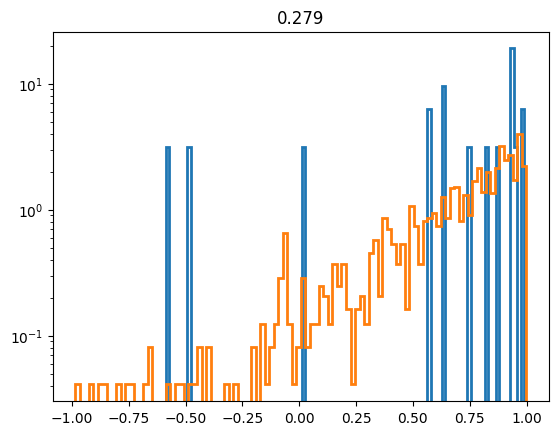

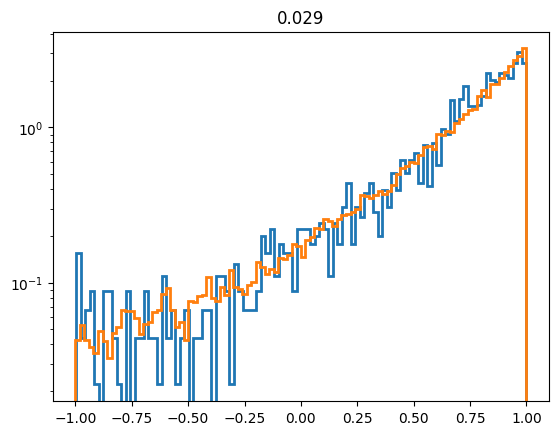

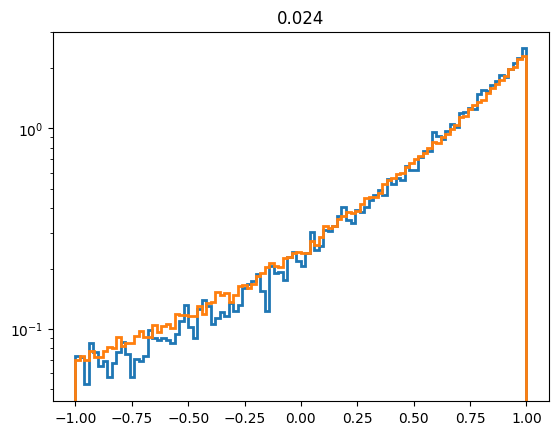

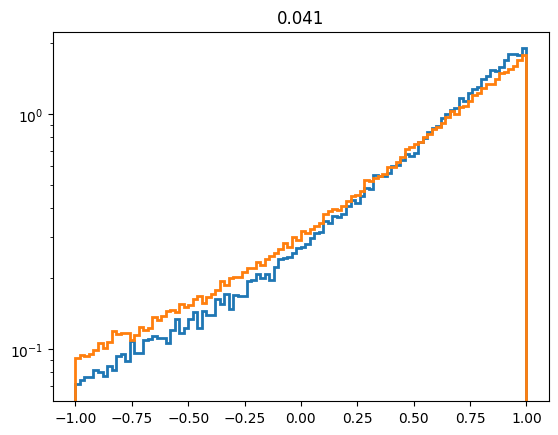

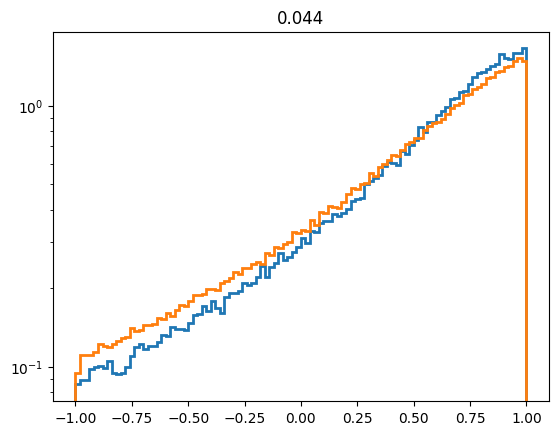

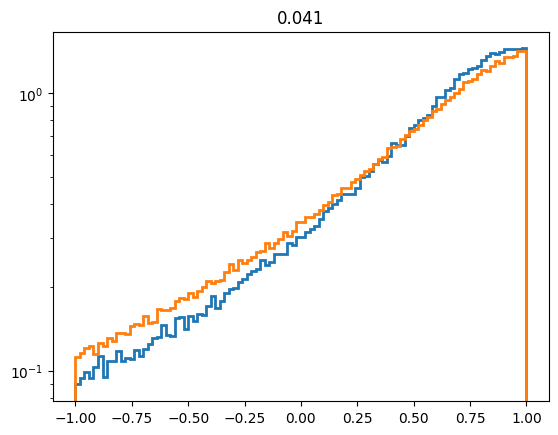

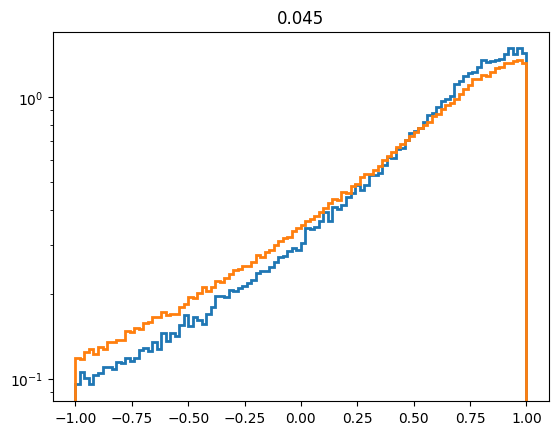

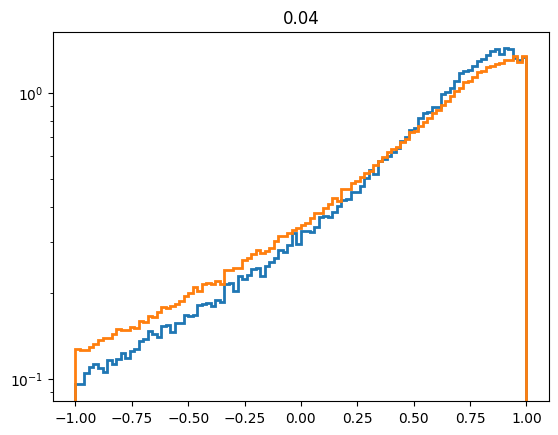

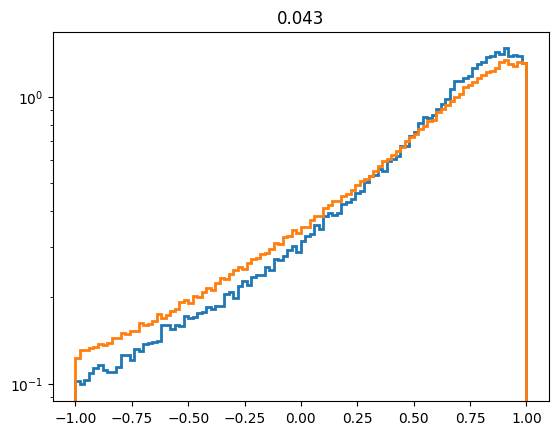

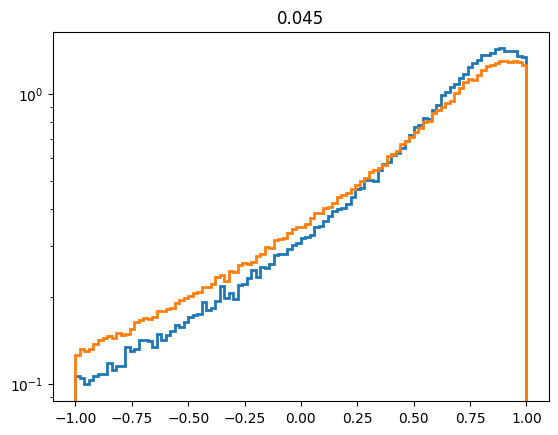

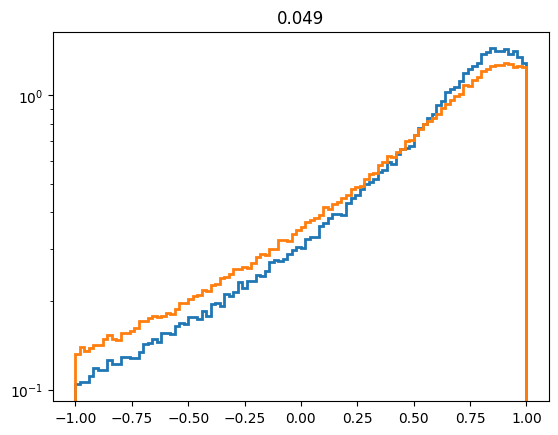

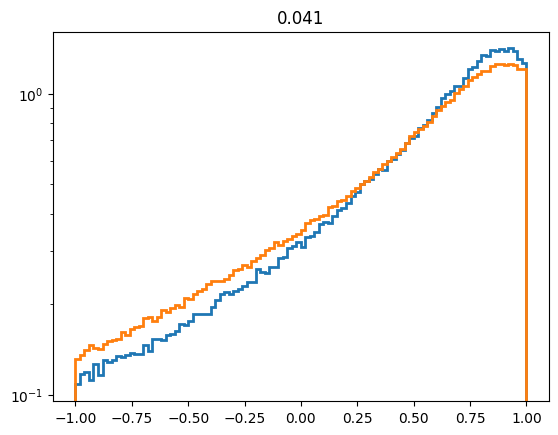

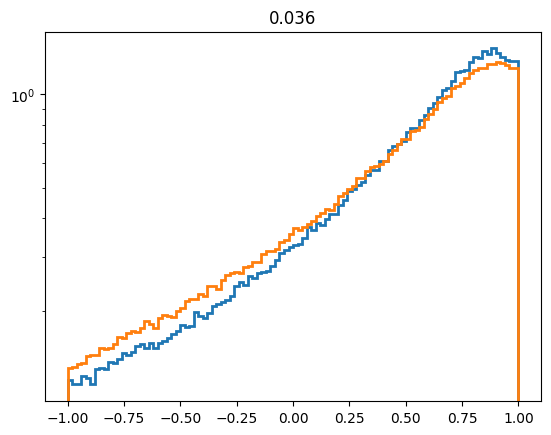

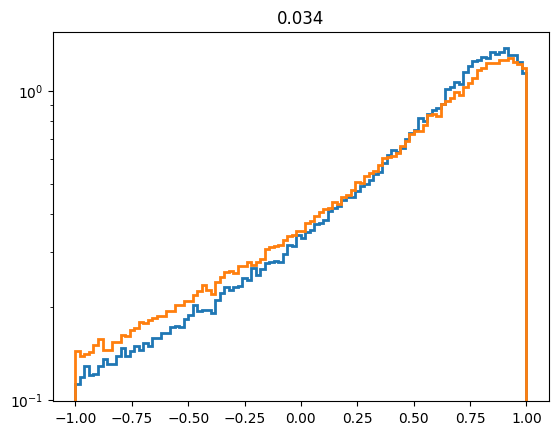

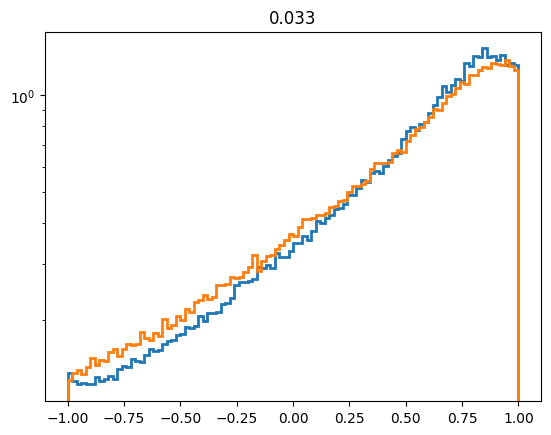

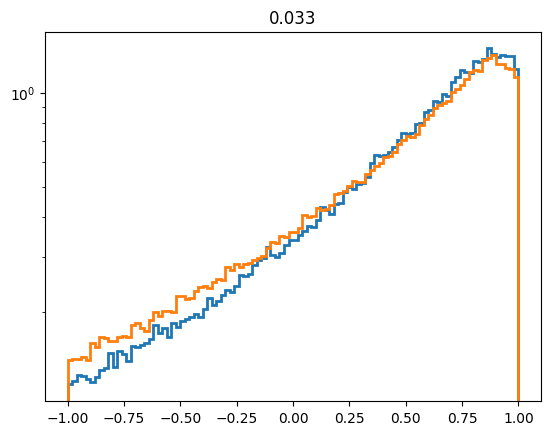

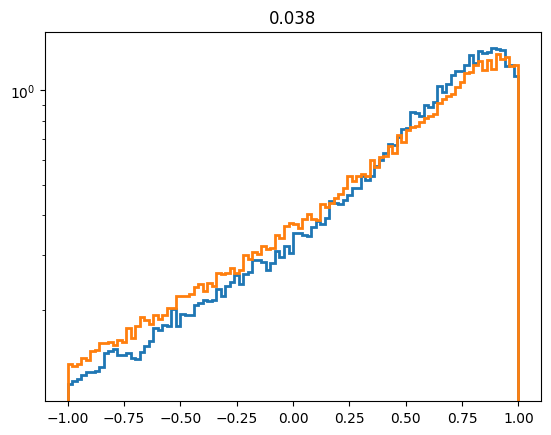

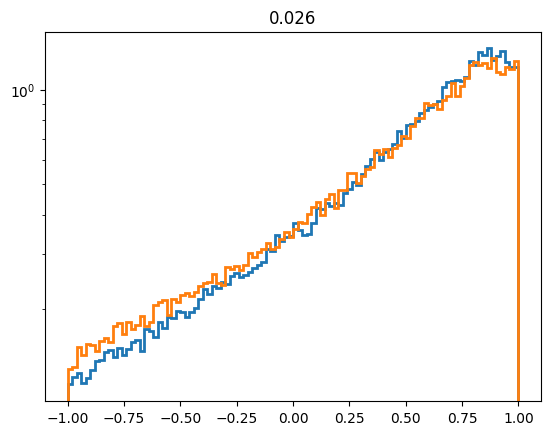

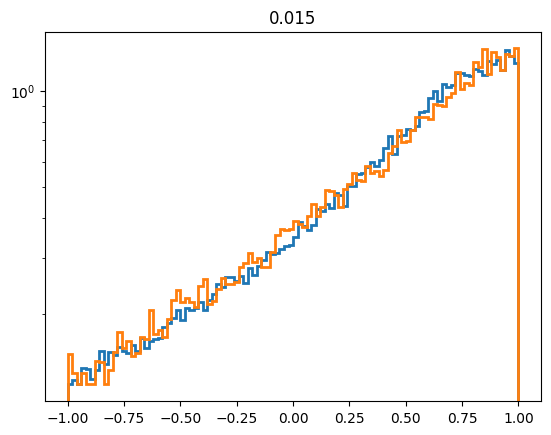

In [17]:
sep_var_angle_reco, p_val_angle_reco, bin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

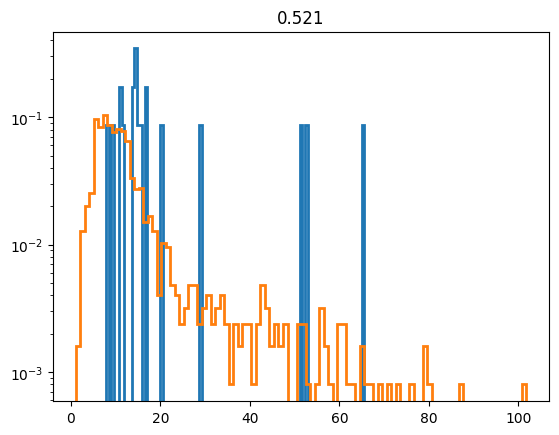

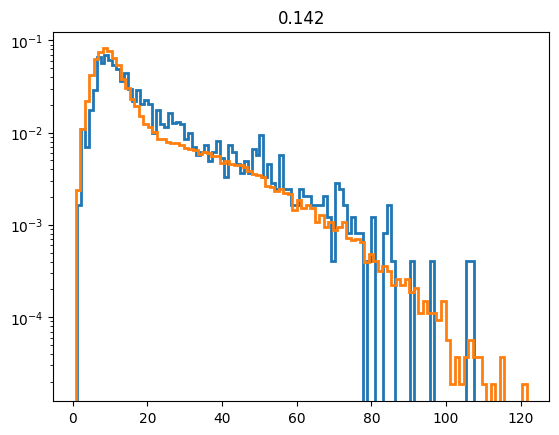

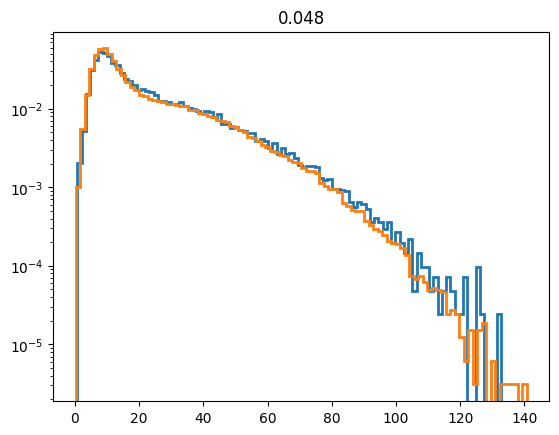

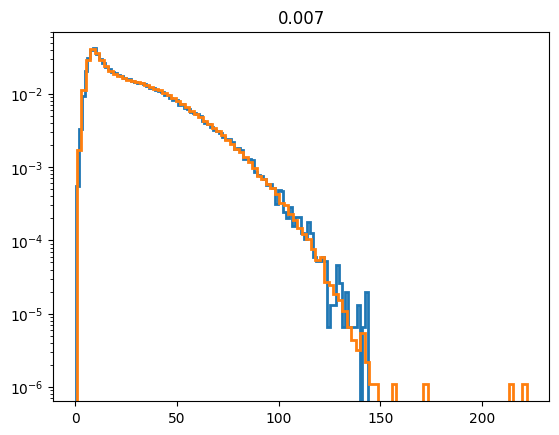

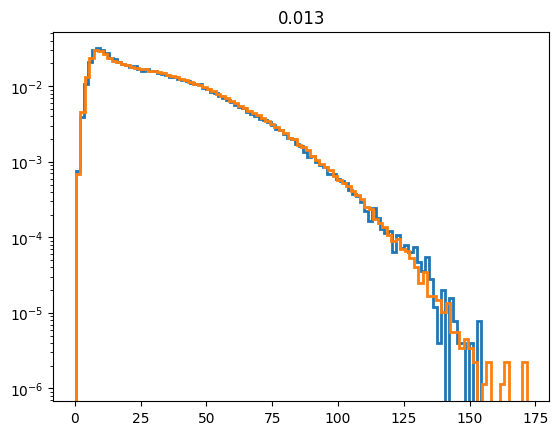

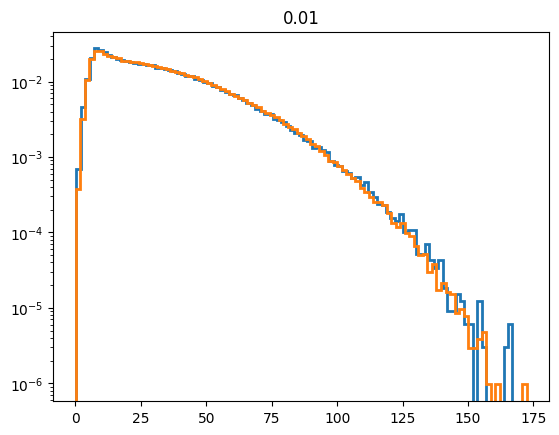

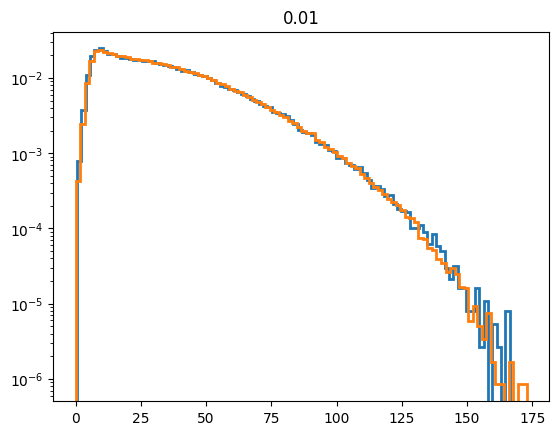

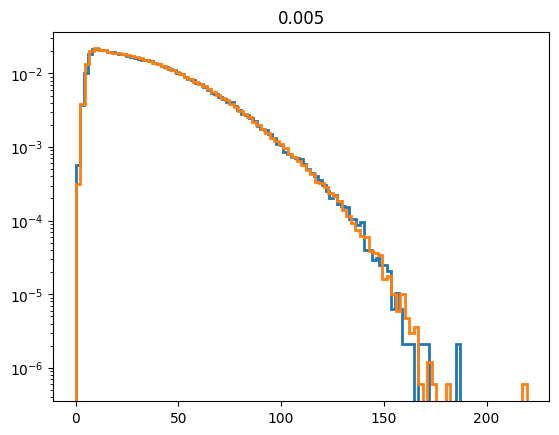

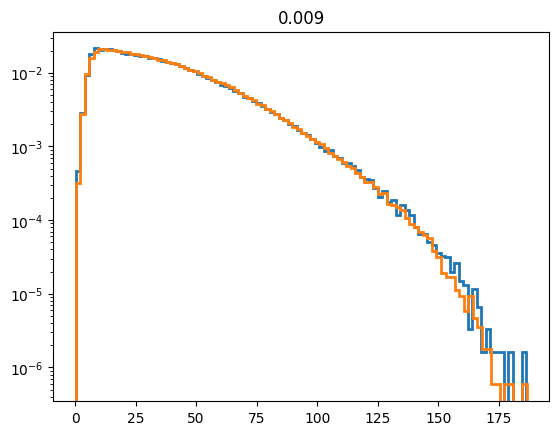

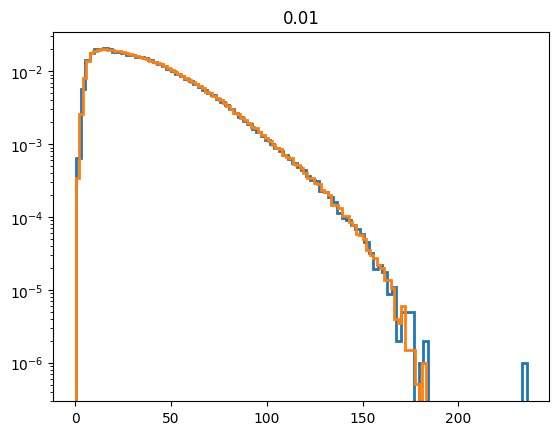

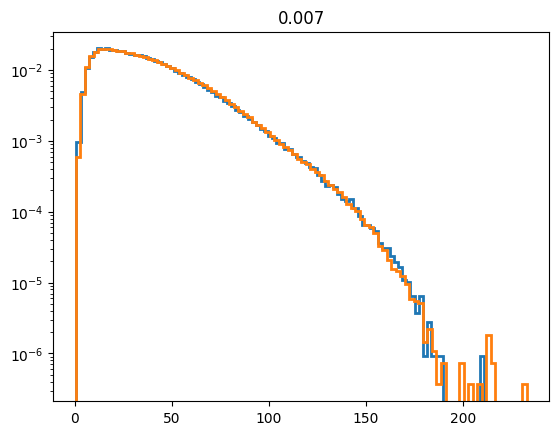

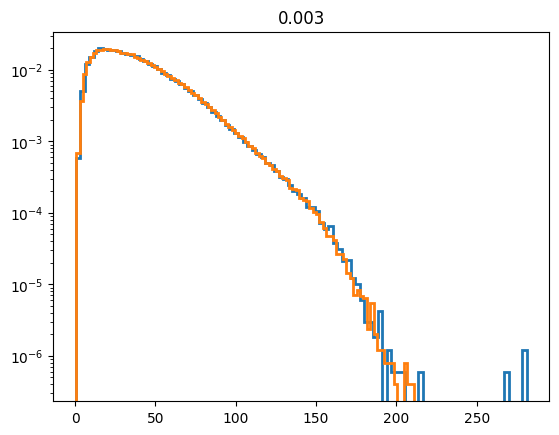

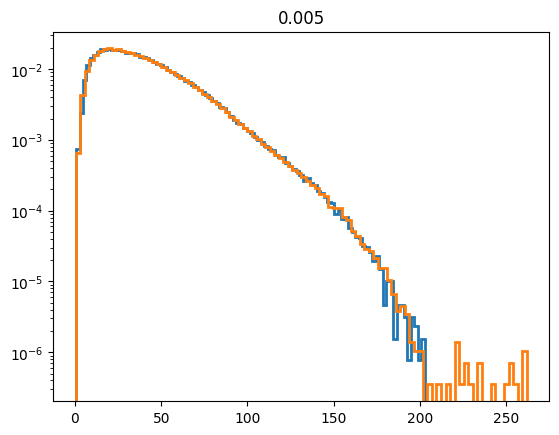

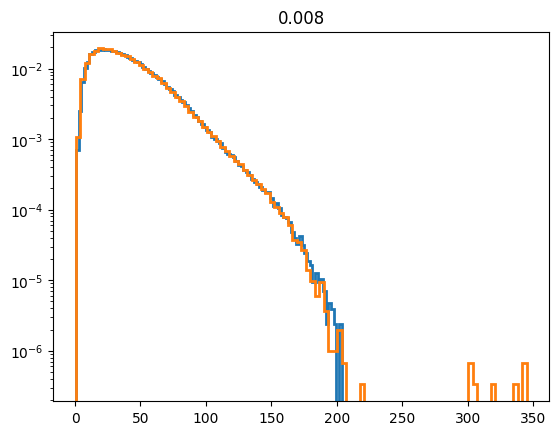

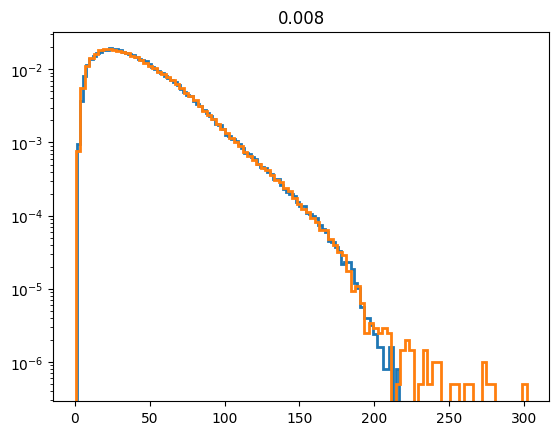

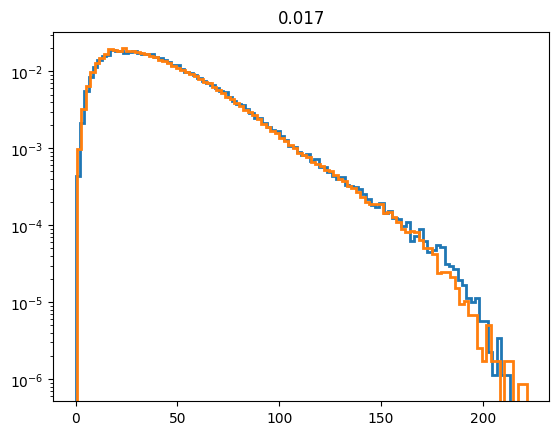

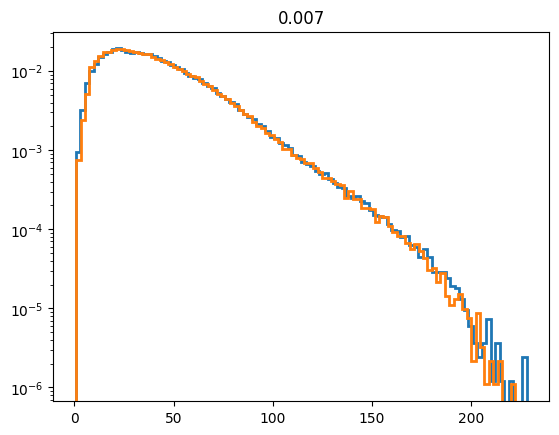

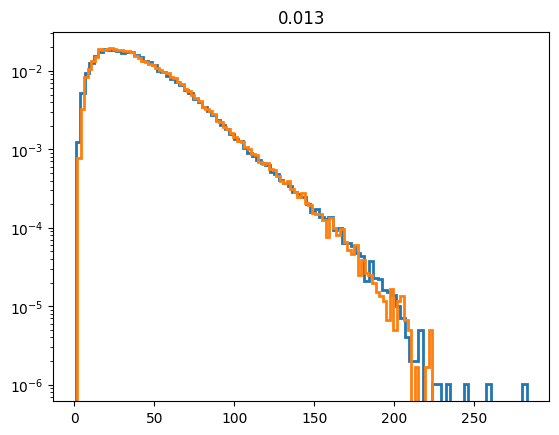

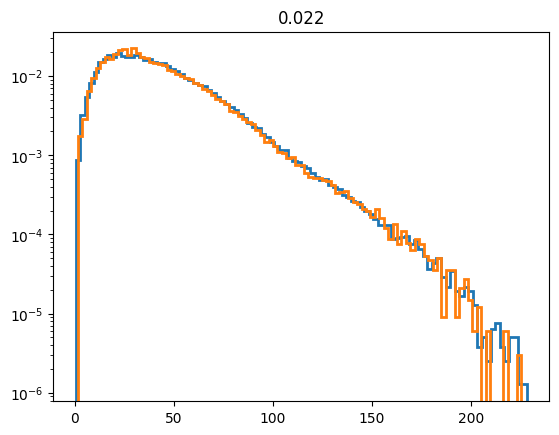

In [20]:
sep_var_distance_reco, p_val_distance_reco, bin_centers_distance_reco = get_statistic(fCC.root.OMMapReco.col('distance'), fNC.root.OMMapReco.col('distance'), 
                                              fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

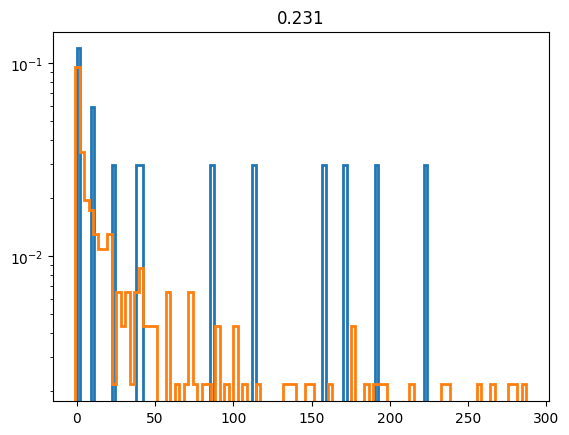

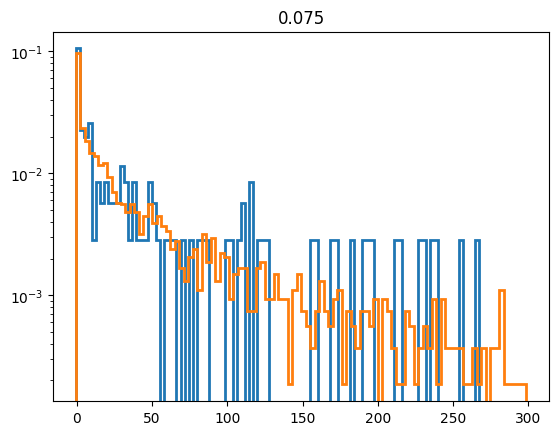

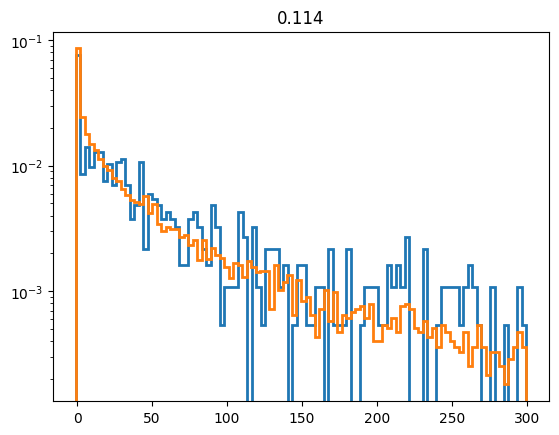

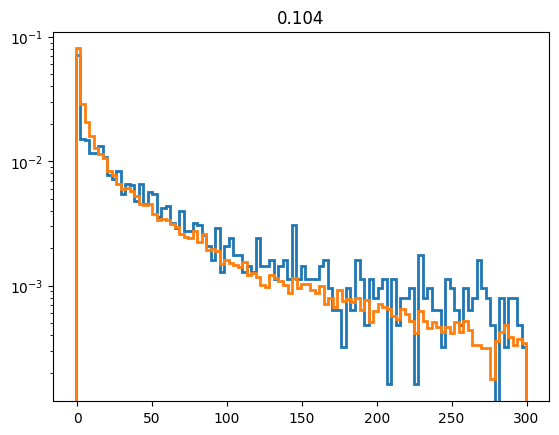

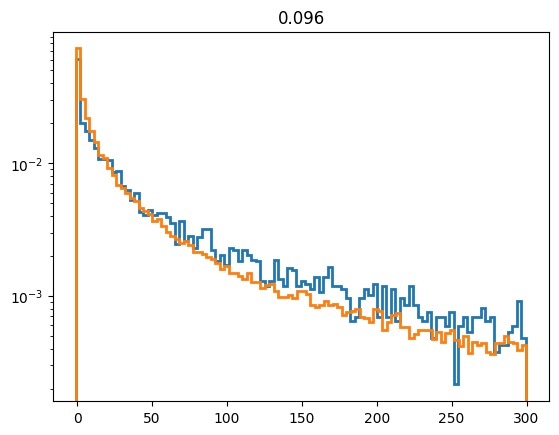

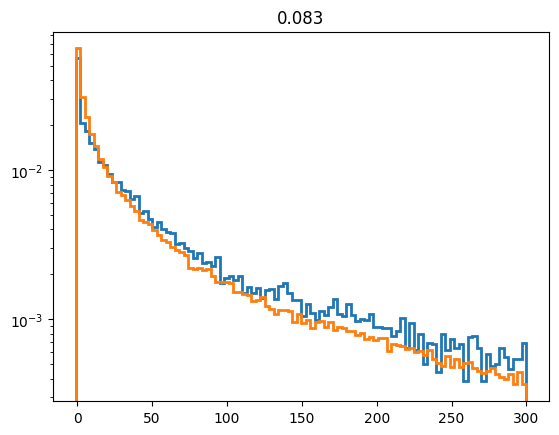

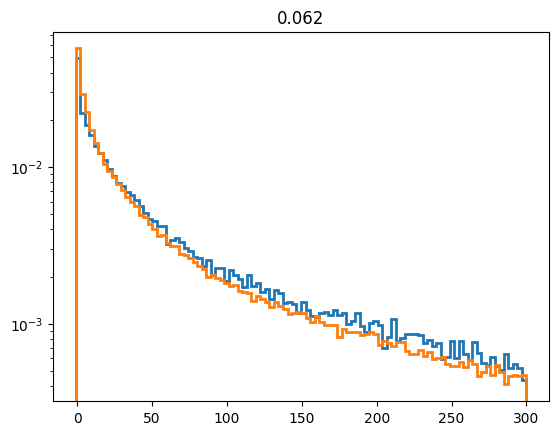

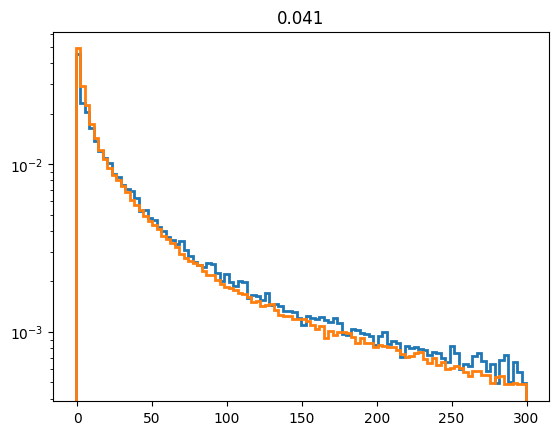

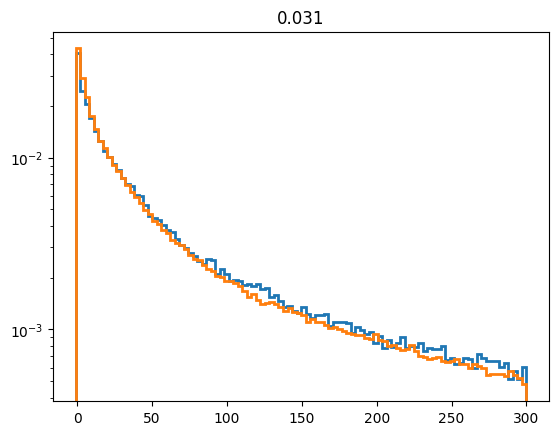

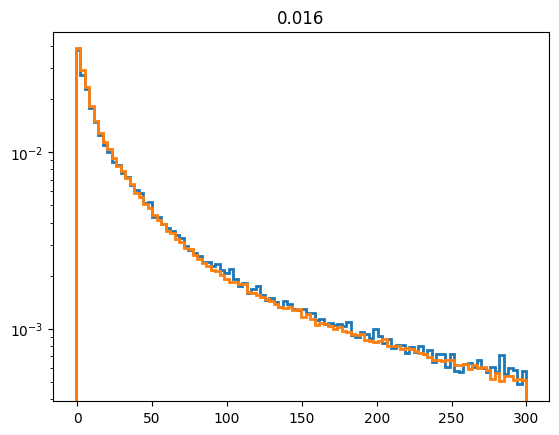

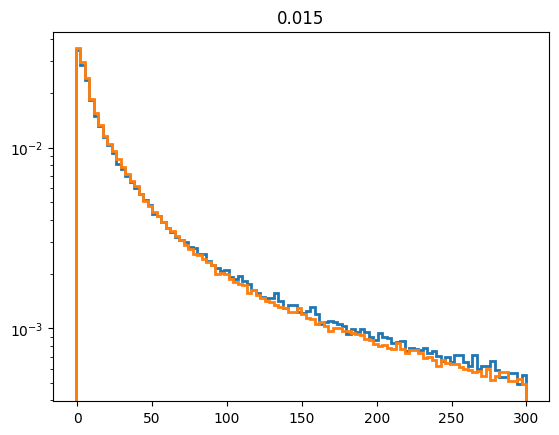

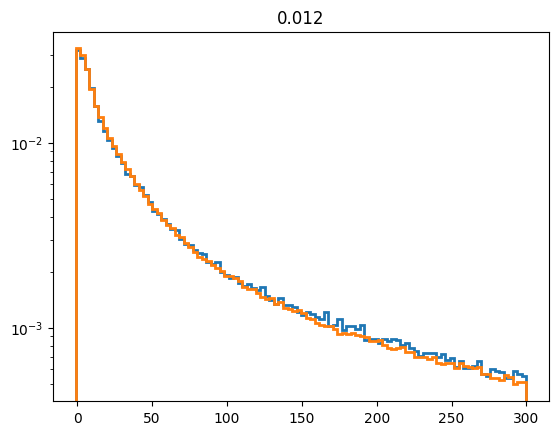

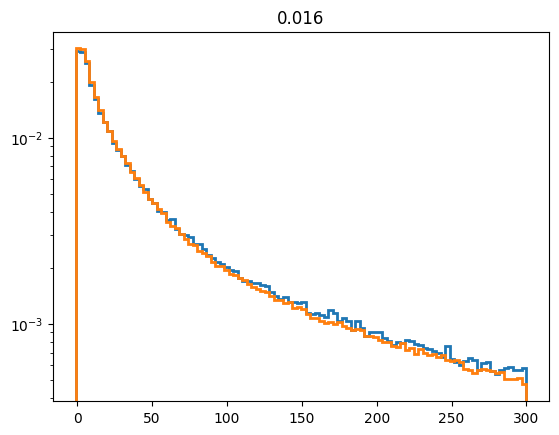

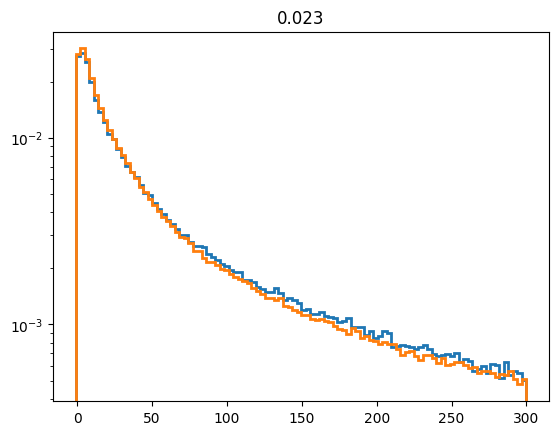

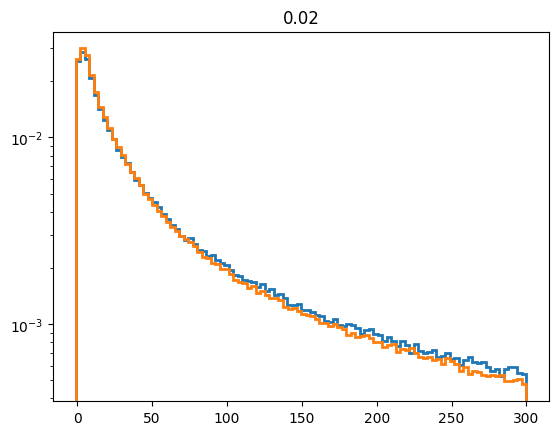

In [21]:
sep_var_tRes_reco, p_val_tRes_reco, bin_centers_tRes_reco = get_statistic(reco_CC[reco_maskCC], reco_NC[reco_maskNC], 
                                              reco_energy_CC[reco_maskCC], reco_energy_NC[reco_maskNC])

In [4]:
#Using energy

sep_var_angle_true, p_val_angle_true, bin_centers_angle_true = get_statistic(np.cos(fCC.root.OMMapTrue.col('angle')), np.cos(fNC.root.OMMapTrue.col('angle')), 
                                              fCC.root.OMMapTrue.col('om_penergy'), fNC.root.OMMapTrue.col('om_senergy'))

sep_var_angle_reco, p_val_angle_reco, bin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

sep_var_distance_true, p_val_distance_true, bin_centers_distance_true = get_statistic(fCC.root.OMMapTrue.col('distance'), fNC.root.OMMapTrue.col('distance'), 
                                              fCC.root.OMMapTrue.col('om_penergy'), fNC.root.OMMapTrue.col('om_senergy'))

sep_var_distance_reco, p_val_distance_reco, bin_centers_distance_reco = get_statistic(fCC.root.OMMapReco.col('distance'), fNC.root.OMMapReco.col('distance'), 
                                              fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

true_CC = fCC.root.OMMapTrue.col('time_residual')
true_energy_CC = fCC.root.OMMapTrue.col('om_penergy')

true_NC = fNC.root.OMMapTrue.col('time_residual')
true_energy_NC = fNC.root.OMMapTrue.col('om_senergy')

reco_CC = fCC.root.OMMapReco.col('time_residual')
reco_energy_CC = fCC.root.OMMapReco.col('om_renergy')

reco_NC = fNC.root.OMMapReco.col('time_residual')
reco_energy_NC = fNC.root.OMMapReco.col('om_renergy')

min_val = -1
max_val = 300
   
true_maskCC = (true_CC>=min_val)&(true_CC<=max_val)
true_maskNC = (true_NC>=min_val)&(true_NC<=max_val)

reco_maskCC = (reco_CC>=min_val)&(reco_CC<=max_val)
reco_maskNC = (reco_NC>=min_val)&(reco_NC<=max_val)

sep_var_tRes_true, p_val_tRes_true, bin_centers_tRes_true = get_statistic(true_CC[true_maskCC], true_NC[true_maskNC], 
                                              true_energy_CC[true_maskCC], true_energy_NC[true_maskNC])

sep_var_tRes_reco, p_val_tRes_reco, bin_centers_tRes_reco = get_statistic(reco_CC[reco_maskCC], reco_NC[reco_maskNC], 
                                              reco_energy_CC[reco_maskCC], reco_energy_NC[reco_maskNC])

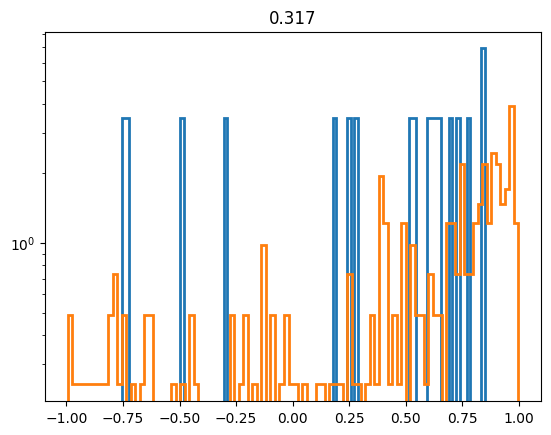

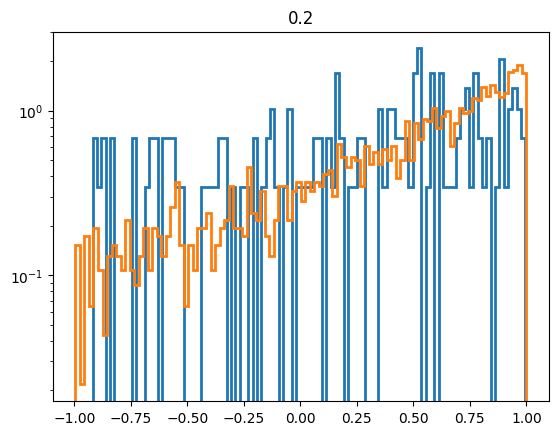

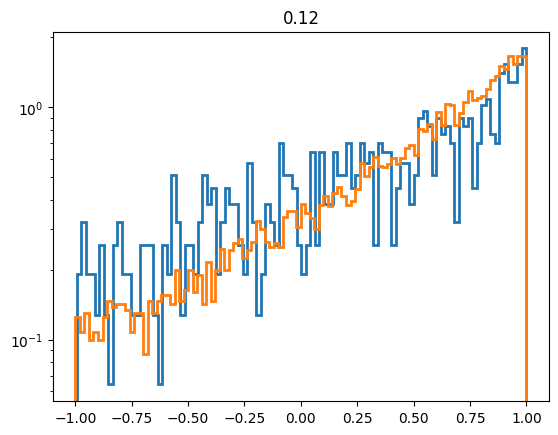

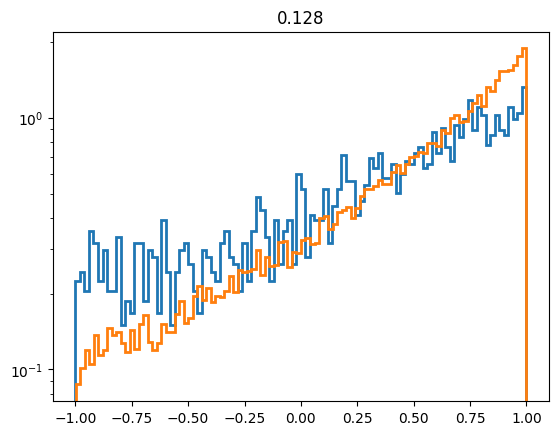

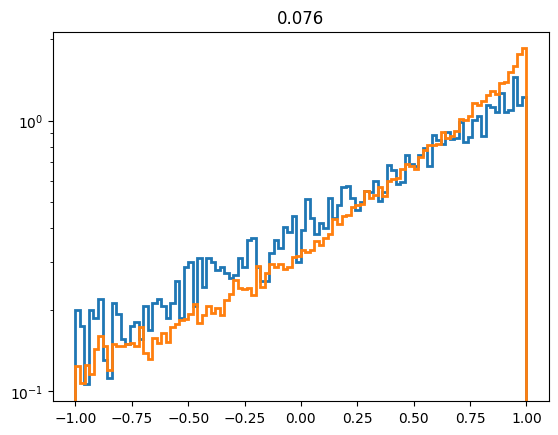

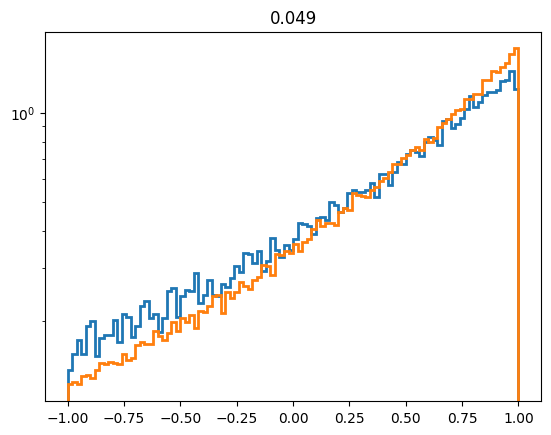

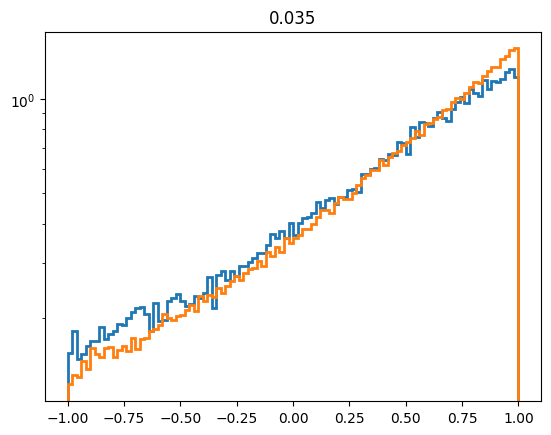

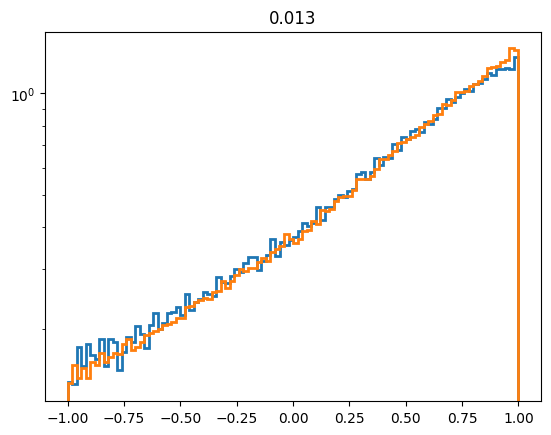

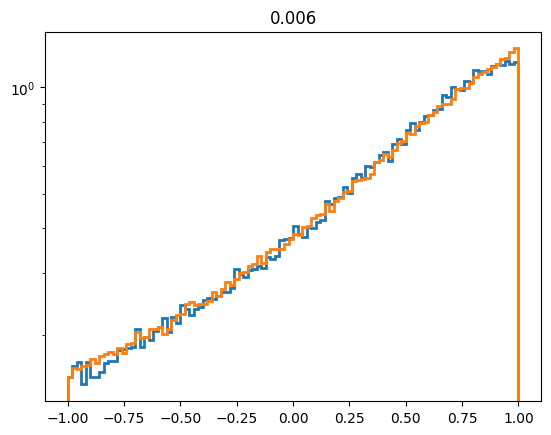

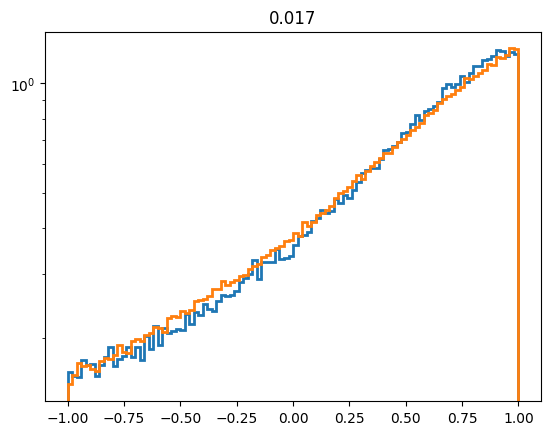

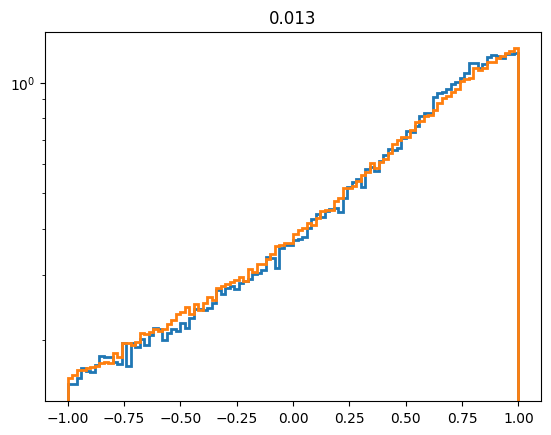

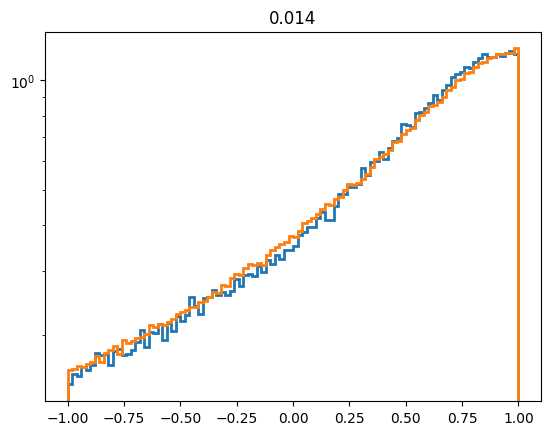

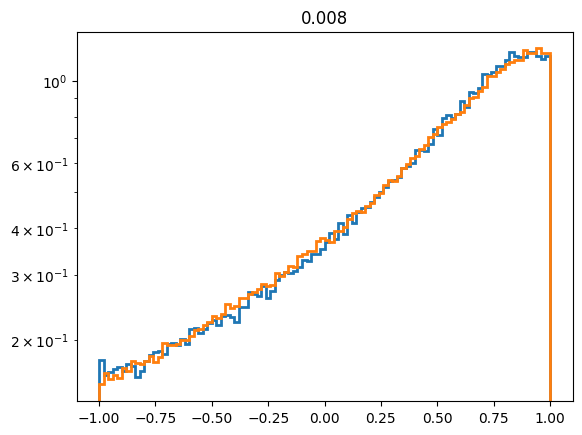

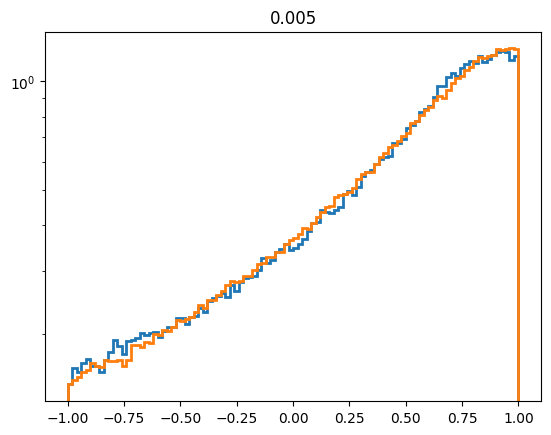

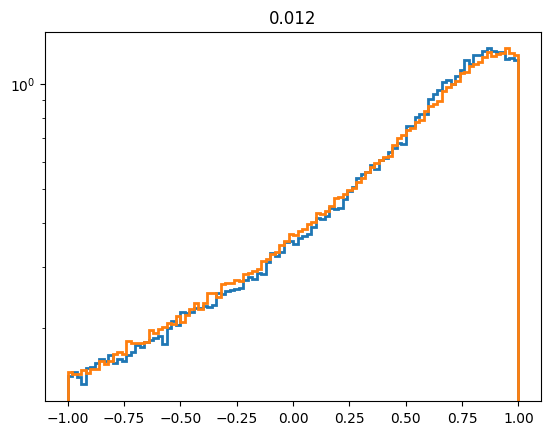

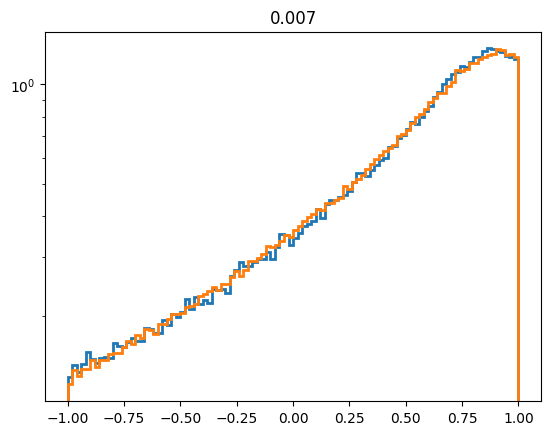

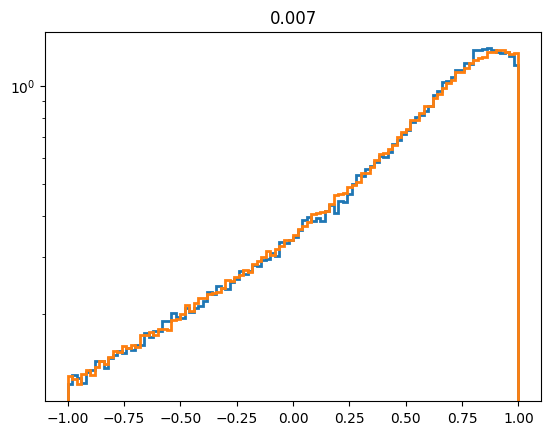

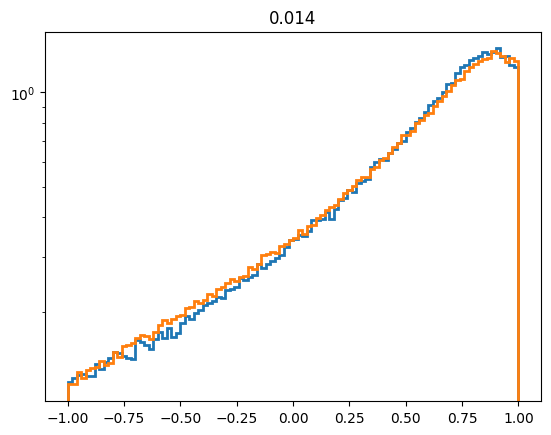

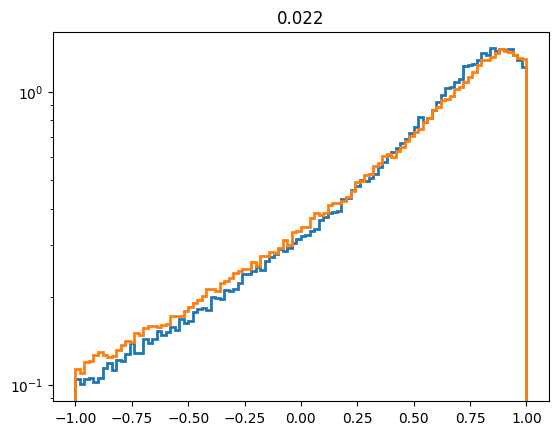

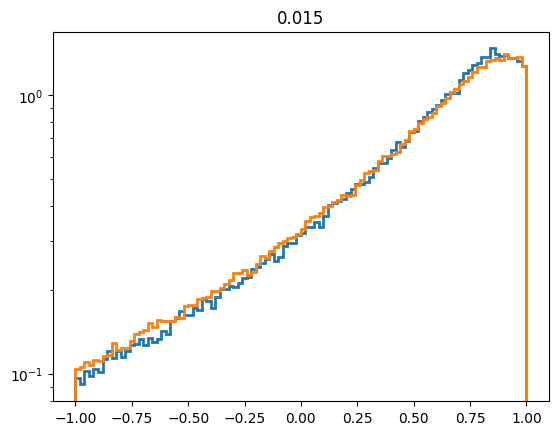

In [18]:
csep_var_angle_reco, cp_val_angle_reco, cbin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              fCC.root.OMMapReco.col('om_total_charge'), fNC.root.OMMapReco.col('om_total_charge'), energy=False)


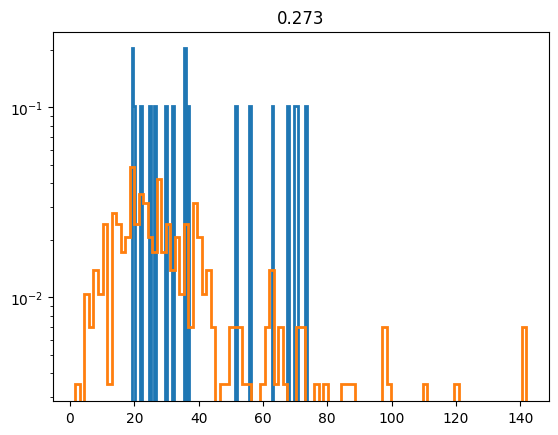

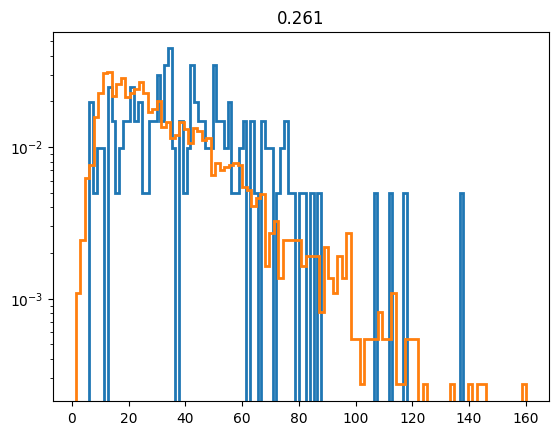

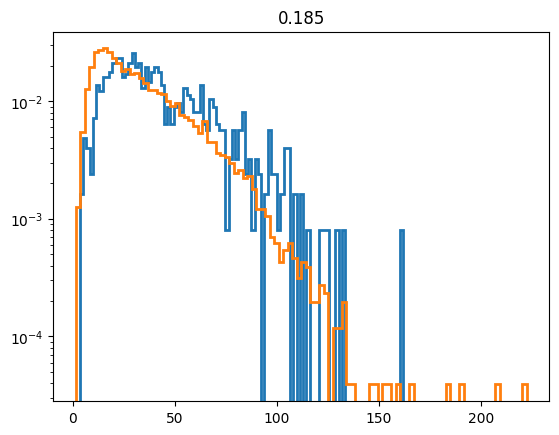

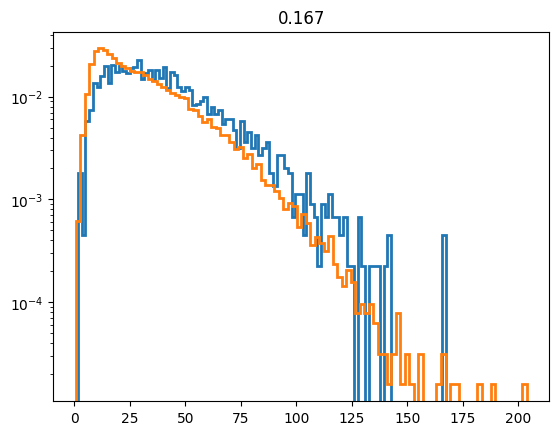

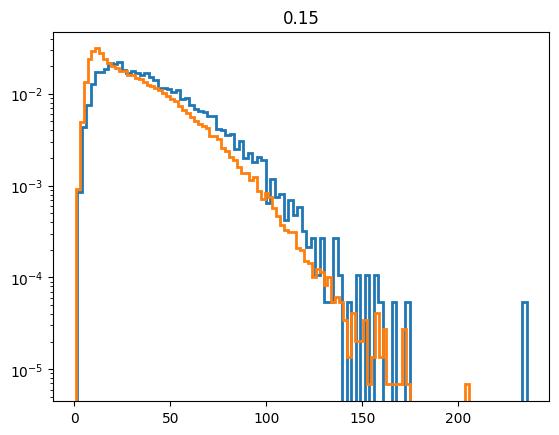

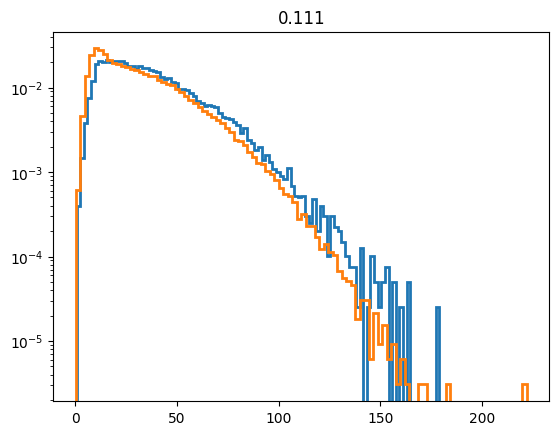

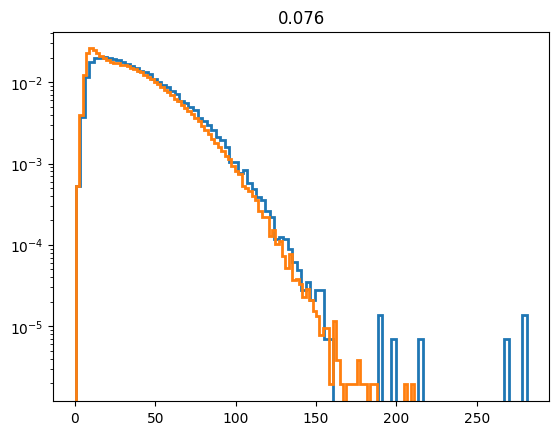

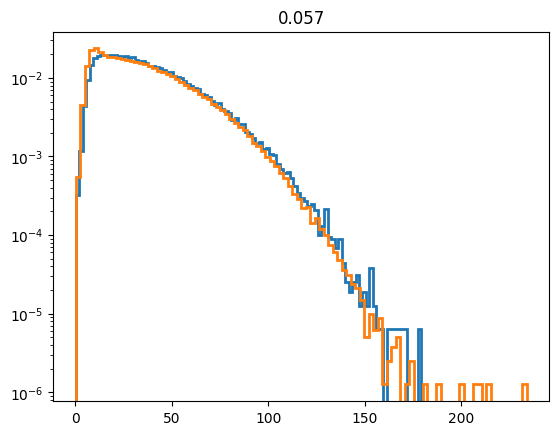

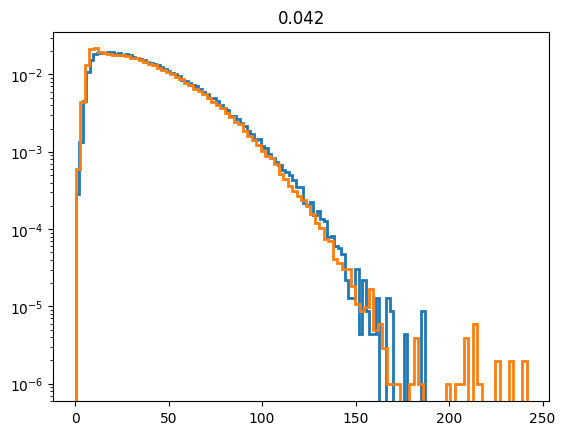

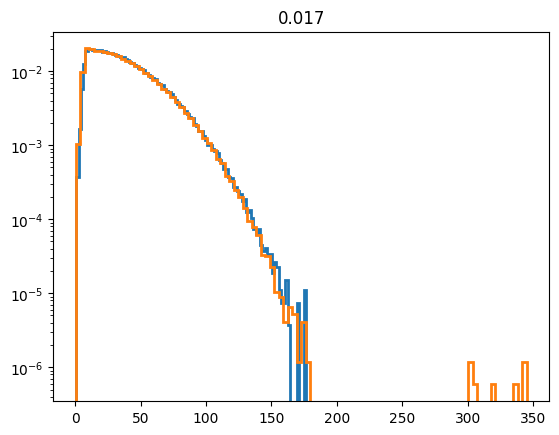

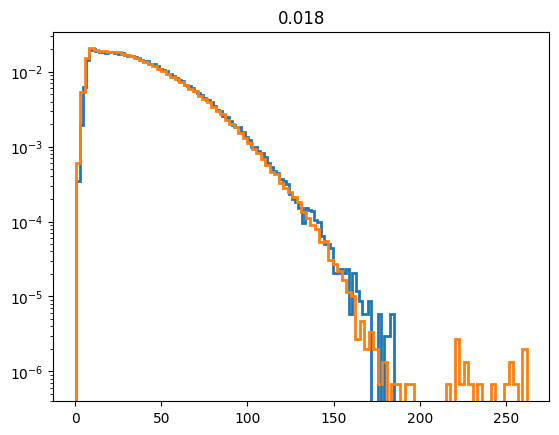

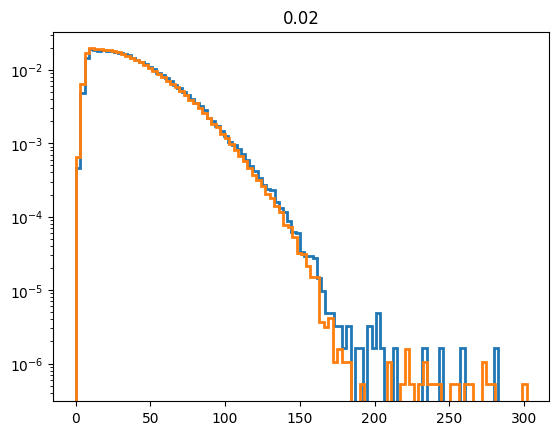

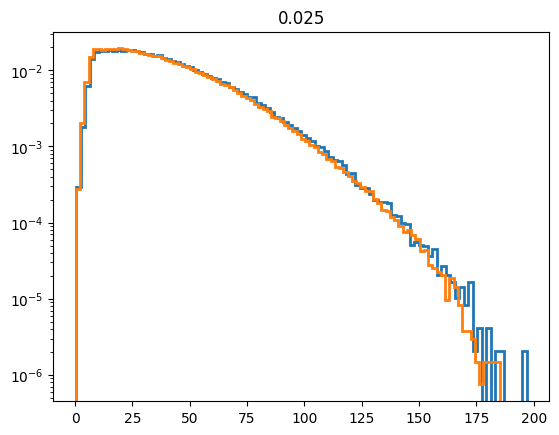

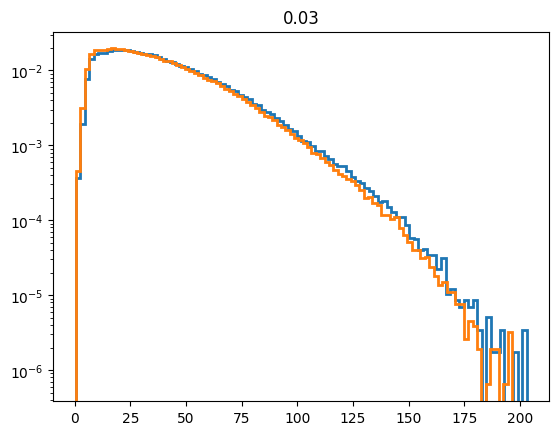

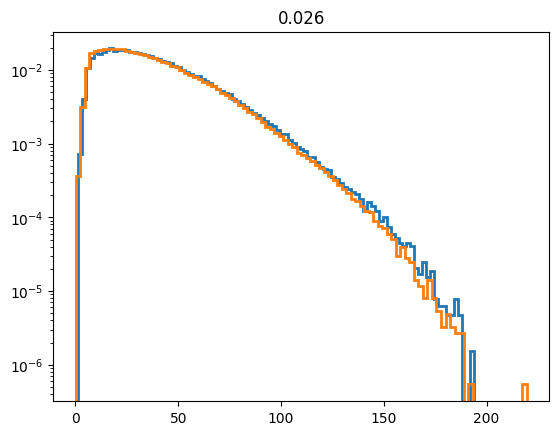

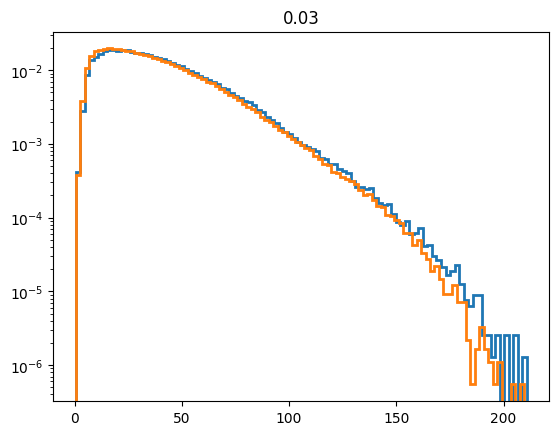

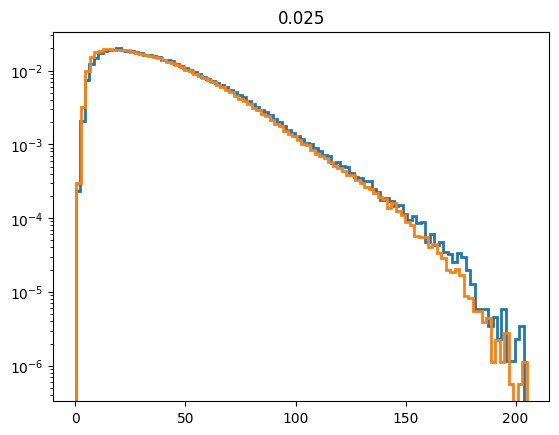

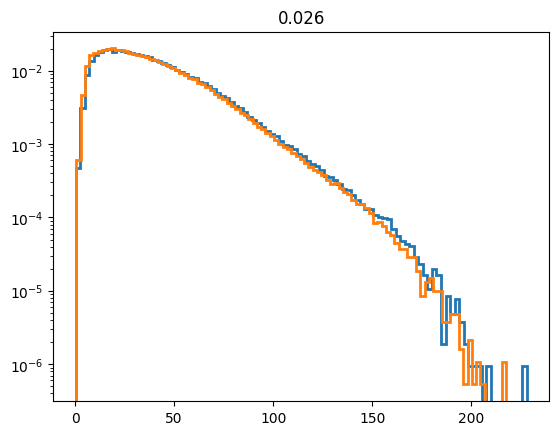

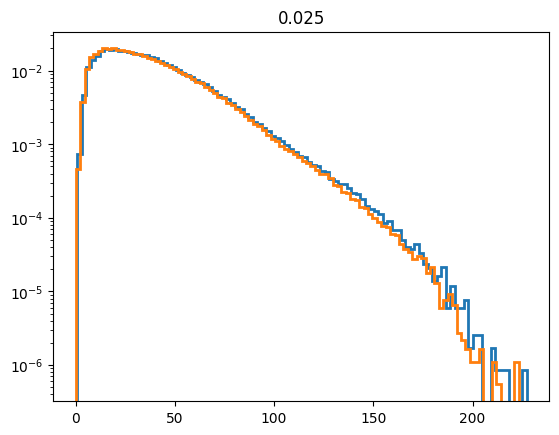

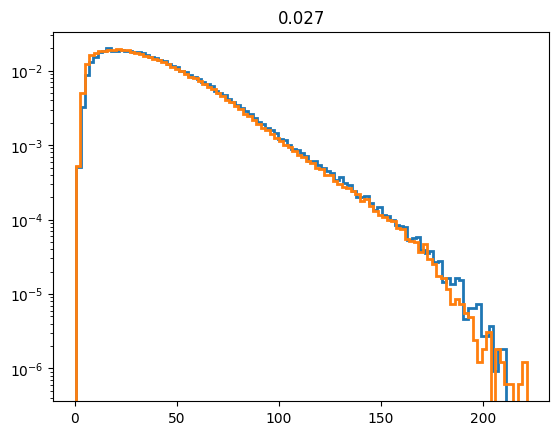

In [23]:
csep_var_distance_reco, cp_val_distance_reco, cbin_centers_distance_reco = get_statistic(fCC.root.OMMapReco.col('distance'), fNC.root.OMMapReco.col('distance'), 
                                              fCC.root.OMMapReco.col('om_total_charge'), fNC.root.OMMapReco.col('om_total_charge'), energy=False)

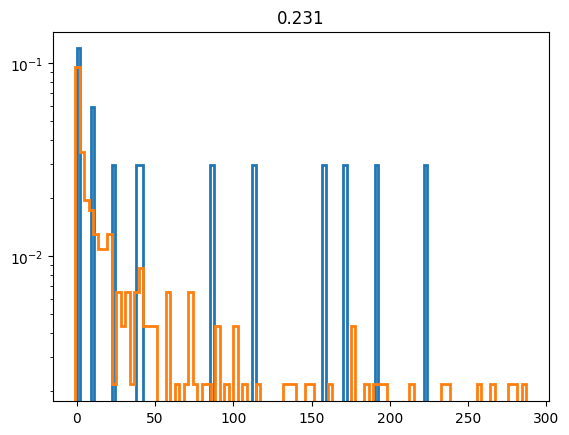

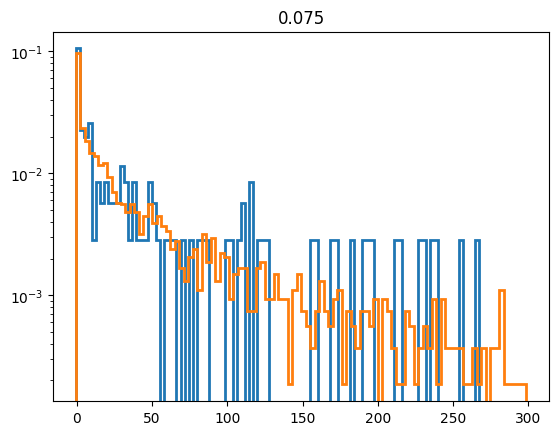

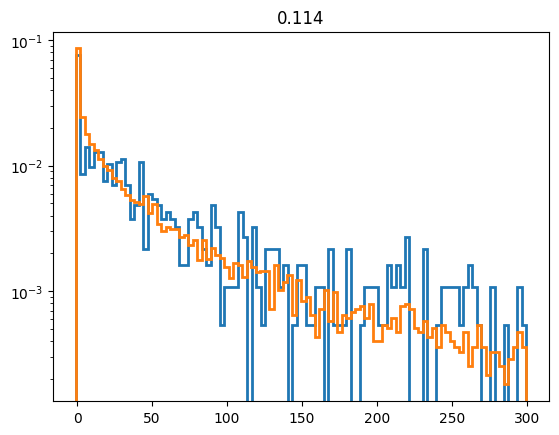

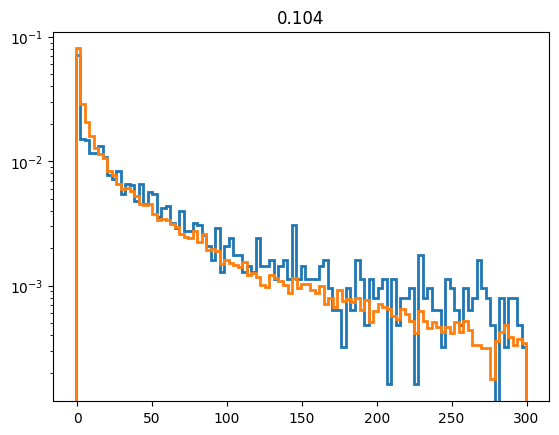

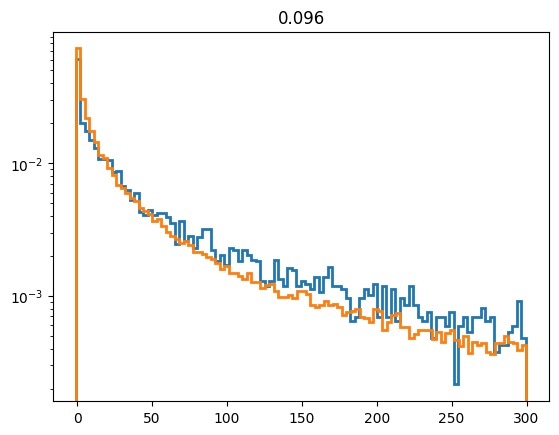

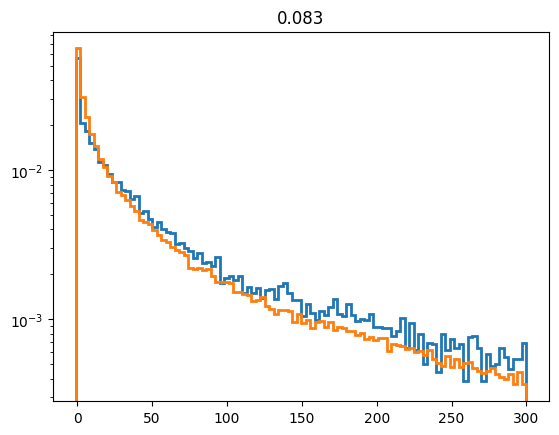

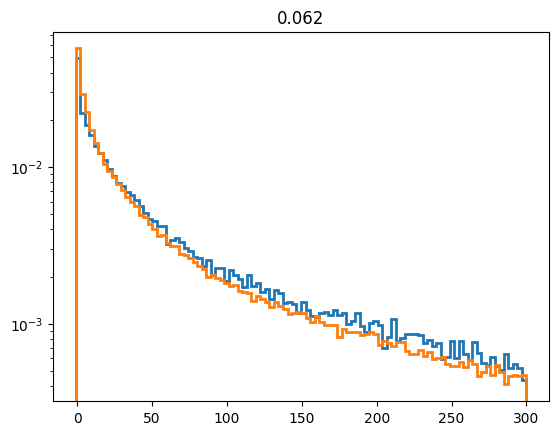

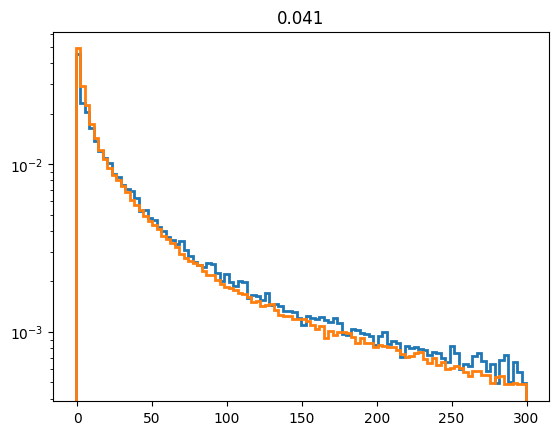

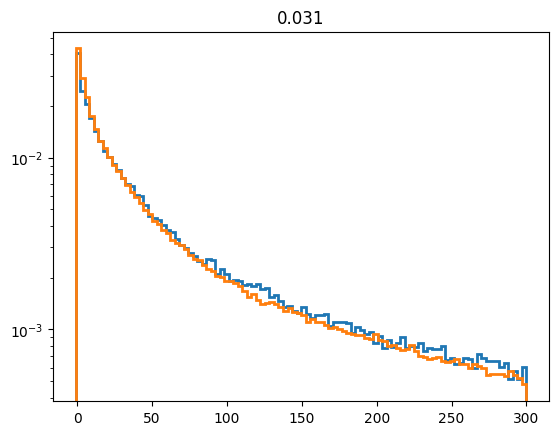

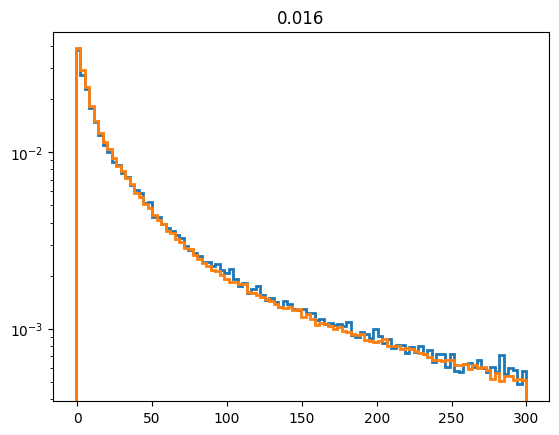

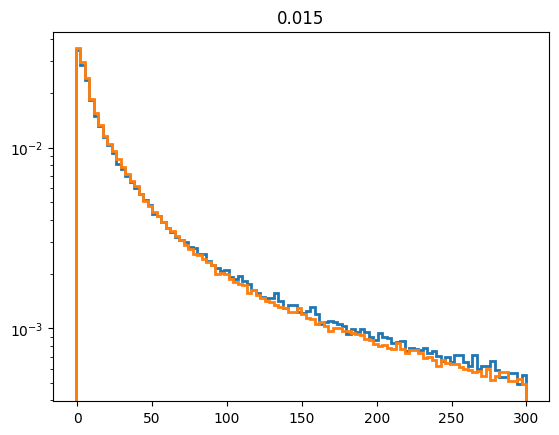

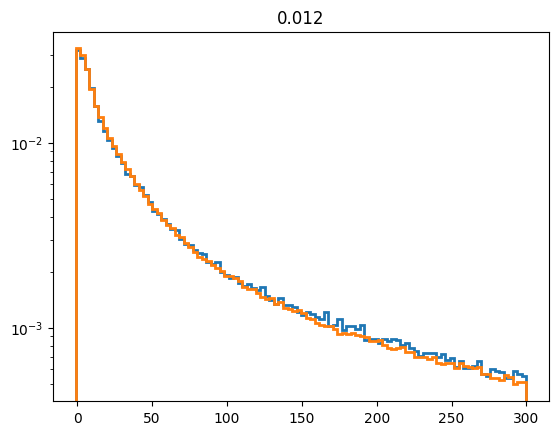

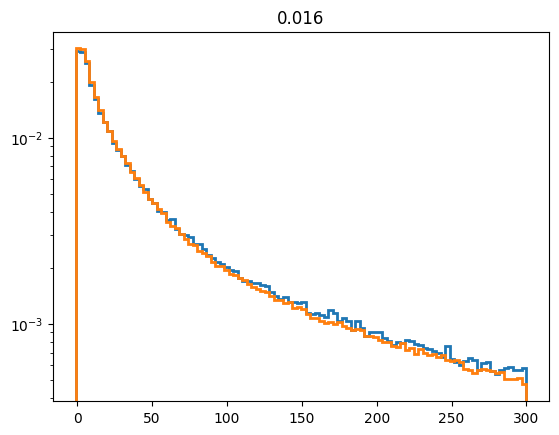

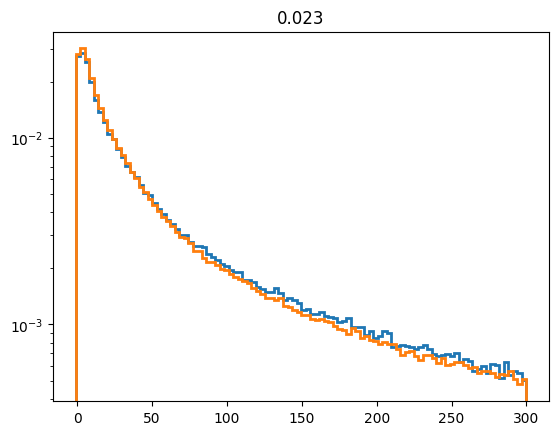

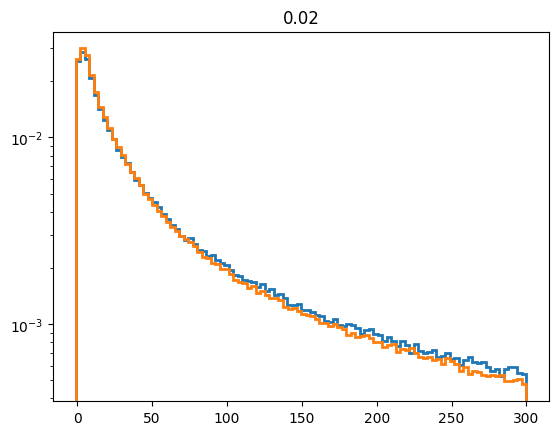

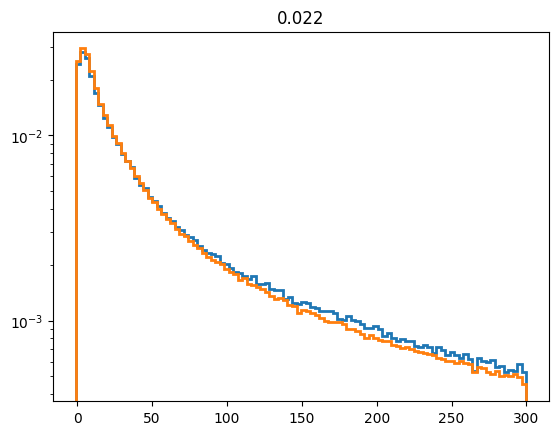

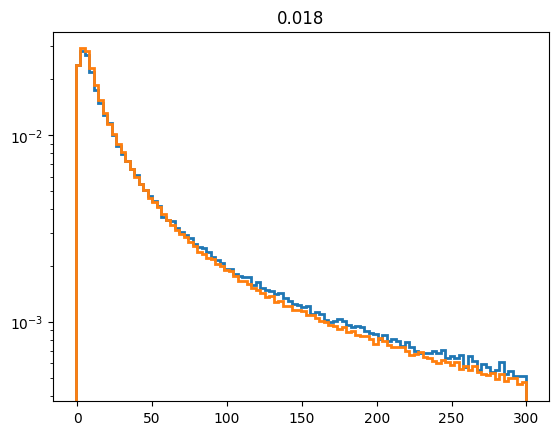

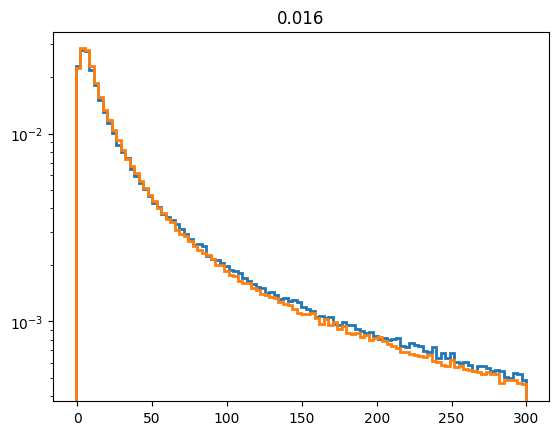

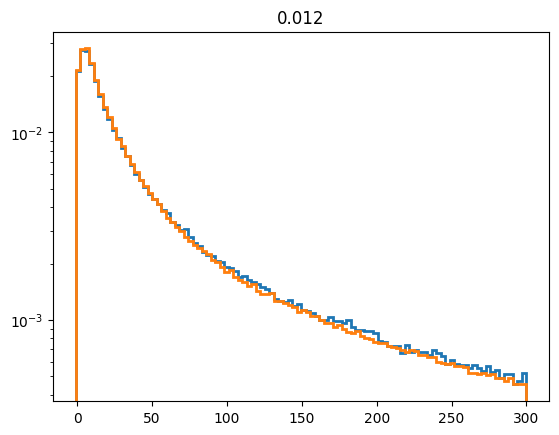

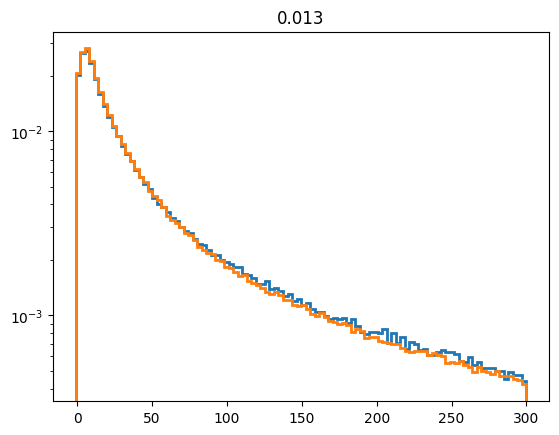

In [24]:
csep_var_tRes_reco, cp_val_tRes_reco, cbin_centers_tRes_reco = get_statistic(reco_CC[reco_maskCC], reco_NC[reco_maskNC], 
                                              reco_energy_CC[reco_maskCC], reco_energy_NC[reco_maskNC], energy=False)

In [5]:
#Using Charge

csep_var_angle_true, cp_val_angle_true, cbin_centers_angle_true = get_statistic(np.cos(fCC.root.OMMapTrue.col('angle')), np.cos(fNC.root.OMMapTrue.col('angle')), 
                                              fCC.root.OMMapTrue.col('om_total_charge'), fNC.root.OMMapTrue.col('om_total_charge'), energy=False)

csep_var_angle_reco, cp_val_angle_reco, cbin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              fCC.root.OMMapReco.col('om_total_charge'), fNC.root.OMMapReco.col('om_total_charge'), energy=False)

csep_var_distance_true, cp_val_distance_true, cbin_centers_distance_true = get_statistic(fCC.root.OMMapTrue.col('distance'), fNC.root.OMMapTrue.col('distance'), 
                                              fCC.root.OMMapTrue.col('om_total_charge'), fNC.root.OMMapTrue.col('om_total_charge'), energy=False)

csep_var_distance_reco, cp_val_distance_reco, cbin_centers_distance_reco = get_statistic(fCC.root.OMMapReco.col('distance'), fNC.root.OMMapReco.col('distance'), 
                                              fCC.root.OMMapReco.col('om_total_charge'), fNC.root.OMMapReco.col('om_total_charge'), energy=False)

true_CC = fCC.root.OMMapTrue.col('time_residual')
true_energy_CC = fCC.root.OMMapTrue.col('om_total_charge')

true_NC = fNC.root.OMMapTrue.col('time_residual')
true_energy_NC = fNC.root.OMMapTrue.col('om_total_charge')

reco_CC = fCC.root.OMMapReco.col('time_residual')
reco_energy_CC = fCC.root.OMMapReco.col('om_total_charge')

reco_NC = fNC.root.OMMapReco.col('time_residual')
reco_energy_NC = fNC.root.OMMapReco.col('om_total_charge')

min_val = -1
max_val = 300
   
true_maskCC = (true_CC>=min_val)&(true_CC<=max_val)
true_maskNC = (true_NC>=min_val)&(true_NC<=max_val)

reco_maskCC = (reco_CC>=min_val)&(reco_CC<=max_val)
reco_maskNC = (reco_NC>=min_val)&(reco_NC<=max_val)

csep_var_tRes_true, cp_val_tRes_true, cbin_centers_tRes_true = get_statistic(true_CC[true_maskCC], true_NC[true_maskNC], 
                                              true_energy_CC[true_maskCC], true_energy_NC[true_maskNC], energy=False)

csep_var_tRes_reco, cp_val_tRes_reco, cbin_centers_tRes_reco = get_statistic(reco_CC[reco_maskCC], reco_NC[reco_maskNC], 
                                              reco_energy_CC[reco_maskCC], reco_energy_NC[reco_maskNC], energy=False)

In [6]:
sep_var_beta1_true, p_val_beta1_true, bin_centers_beta1_true = get_statistic(fCC.root.Beta1.col('value'), 
                                                                             fNC.root.Beta1.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta1_reco, p_val_beta1_reco, bin_centers_beta1_reco = get_statistic(fCC.root.Beta1Reco.col('value'), 
                                                                             fNC.root.Beta1Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta2_true, p_val_beta2_true, bin_centers_beta2_true = get_statistic(fCC.root.Beta2.col('value'), 
                                                                             fNC.root.Beta2.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta2_reco, p_val_beta2_reco, bin_centers_beta2_reco = get_statistic(fCC.root.Beta2Reco.col('value'), 
                                                                             fNC.root.Beta2Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta3_true, p_val_beta3_true, bin_centers_beta3_true = get_statistic(fCC.root.Beta3.col('value'), 
                                                                             fNC.root.Beta3.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta3_reco, p_val_beta3_reco, bin_centers_beta3_reco = get_statistic(fCC.root.Beta3Reco.col('value'), 
                                                                             fNC.root.Beta3Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta4_true, p_val_beta4_true, bin_centers_beta4_true = get_statistic(fCC.root.Beta4.col('value'), 
                                                                             fNC.root.Beta4.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta4_reco, p_val_beta4_reco, bin_centers_beta4_reco = get_statistic(fCC.root.Beta4Reco.col('value'), 
                                                                             fNC.root.Beta4Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta5_true, p_val_beta5_true, bin_centers_beta5_true = get_statistic(fCC.root.Beta5.col('value'), 
                                                                             fNC.root.Beta5.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta5_reco, p_val_beta5_reco, bin_centers_beta5_reco = get_statistic(fCC.root.Beta5Reco.col('value'), 
                                                                             fNC.root.Beta5Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

In [7]:
csep_var_beta1_true, cp_val_beta1_true, cbin_centers_beta1_true = get_statistic(fCC.root.Beta1.col('value'), 
                                                                             fNC.root.Beta1.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta1_reco, cp_val_beta1_reco, cbin_centers_beta1_reco = get_statistic(fCC.root.Beta1Reco.col('value'), 
                                                                             fNC.root.Beta1Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta2_true, cp_val_beta2_true, cbin_centers_beta2_true = get_statistic(fCC.root.Beta2.col('value'), 
                                                                             fNC.root.Beta2.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta2_reco, cp_val_beta2_reco, cbin_centers_beta2_reco = get_statistic(fCC.root.Beta2Reco.col('value'), 
                                                                             fNC.root.Beta2Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta3_true, cp_val_beta3_true, cbin_centers_beta3_true = get_statistic(fCC.root.Beta3.col('value'), 
                                                                             fNC.root.Beta3.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta3_reco, cp_val_beta3_reco, cbin_centers_beta3_reco = get_statistic(fCC.root.Beta3Reco.col('value'), 
                                                                             fNC.root.Beta3Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta4_true, cp_val_beta4_true, cbin_centers_beta4_true = get_statistic(fCC.root.Beta4.col('value'), 
                                                                             fNC.root.Beta4.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta4_reco, cp_val_beta4_reco, cbin_centers_beta4_reco = get_statistic(fCC.root.Beta4Reco.col('value'), 
                                                                             fNC.root.Beta4Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta5_true, cp_val_beta5_true, cbin_centers_beta5_true = get_statistic(fCC.root.Beta5.col('value'), 
                                                                             fNC.root.Beta5.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta5_reco, cp_val_beta5_reco, cbin_centers_beta5_reco = get_statistic(fCC.root.Beta5Reco.col('value'), 
                                                                             fNC.root.Beta5Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

In [8]:
true_cogDistCC = np.sqrt((fCC.root.TrueX.col('value')-fCC.root.CogX.col('value'))**2+
                    (fCC.root.TrueY.col('value')-fCC.root.CogY.col('value'))**2+ 
                    (fCC.root.TrueZ.col('value')-fCC.root.CogZ.col('value'))**2)

true_cogDistNC = np.sqrt((fNC.root.TrueX.col('value')-fNC.root.CogX.col('value'))**2+
                    (fNC.root.TrueY.col('value')-fNC.root.CogY.col('value'))**2+
                    (fNC.root.TrueZ.col('value')-fNC.root.CogZ.col('value'))**2)

In [9]:
reco_cogDistCC = np.sqrt((fCC.root.RecoX.col('value')-fCC.root.CogX.col('value'))**2+
                    (fCC.root.RecoY.col('value')-fCC.root.CogY.col('value'))**2+ 
                    (fCC.root.RecoZ.col('value')-fCC.root.CogZ.col('value'))**2)

reco_cogDistNC = np.sqrt((fNC.root.RecoX.col('value')-fNC.root.CogX.col('value'))**2+
                    (fNC.root.RecoY.col('value')-fNC.root.CogY.col('value'))**2+
                    (fNC.root.RecoZ.col('value')-fNC.root.CogZ.col('value'))**2)

In [10]:
# cog energy

sep_var_cog_true, p_val_cog_true, bin_centers_cog_true = get_statistic(true_cogDistCC, true_cogDistNC, 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_cog_reco, p_val_cog_reco, bin_centers_cog_reco = get_statistic(reco_cogDistCC, reco_cogDistNC, 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

In [11]:
# cog charge

csep_var_cog_true, cp_val_cog_true, cbin_centers_cog_true = get_statistic(true_cogDistCC, true_cogDistNC, 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_cog_reco, cp_val_cog_reco, cbin_centers_cog_reco = get_statistic(reco_cogDistCC, reco_cogDistNC, 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

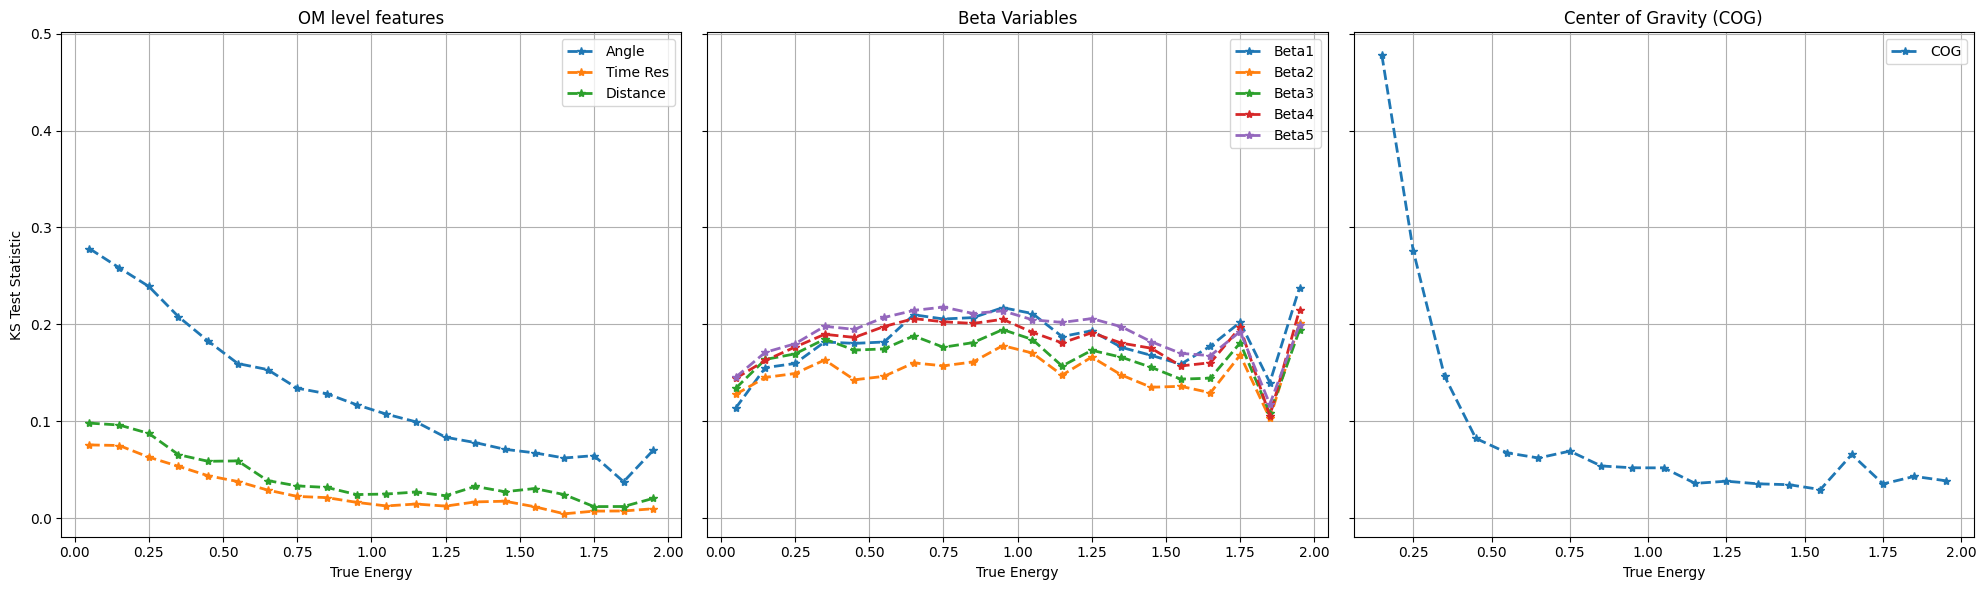

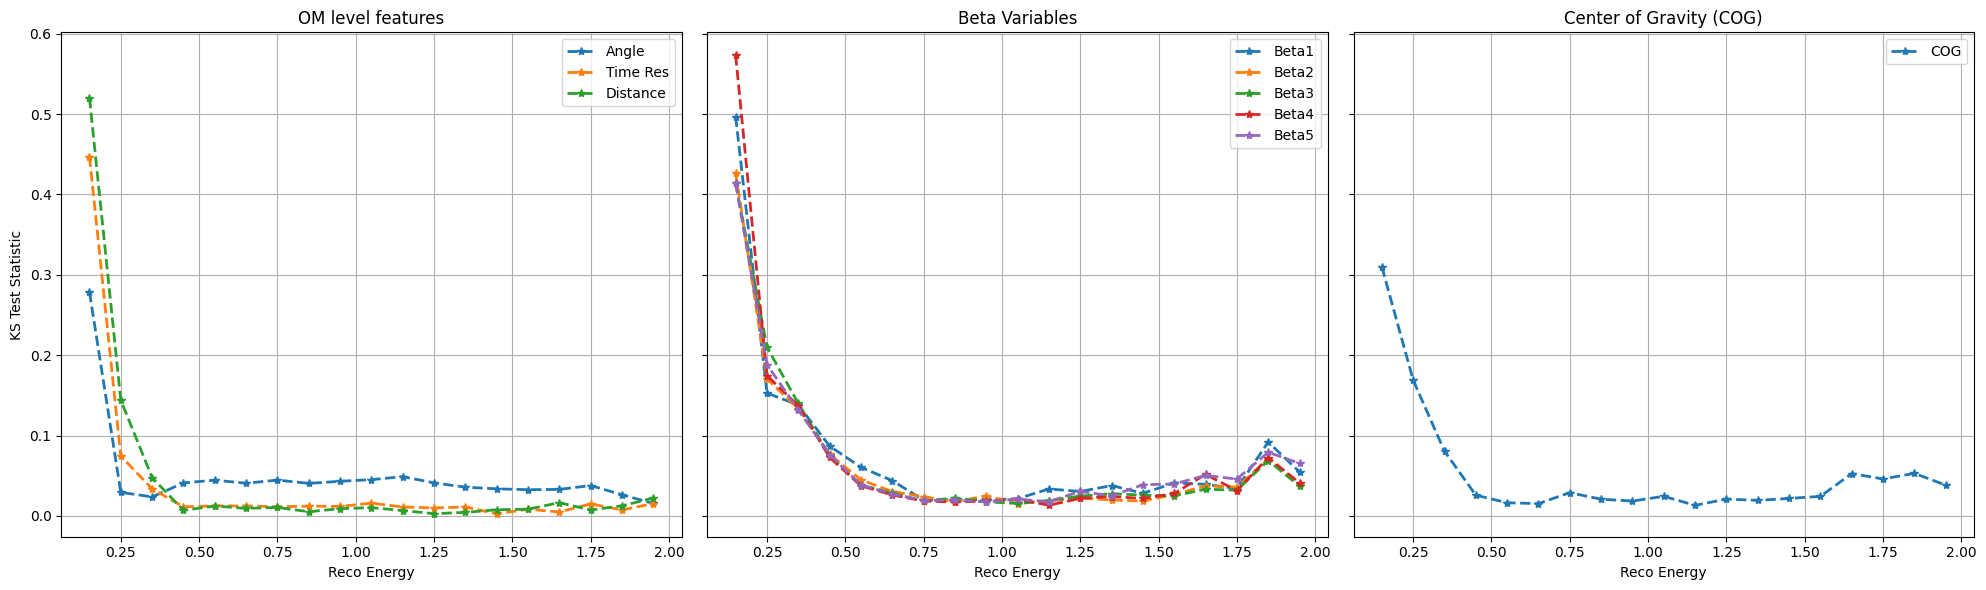

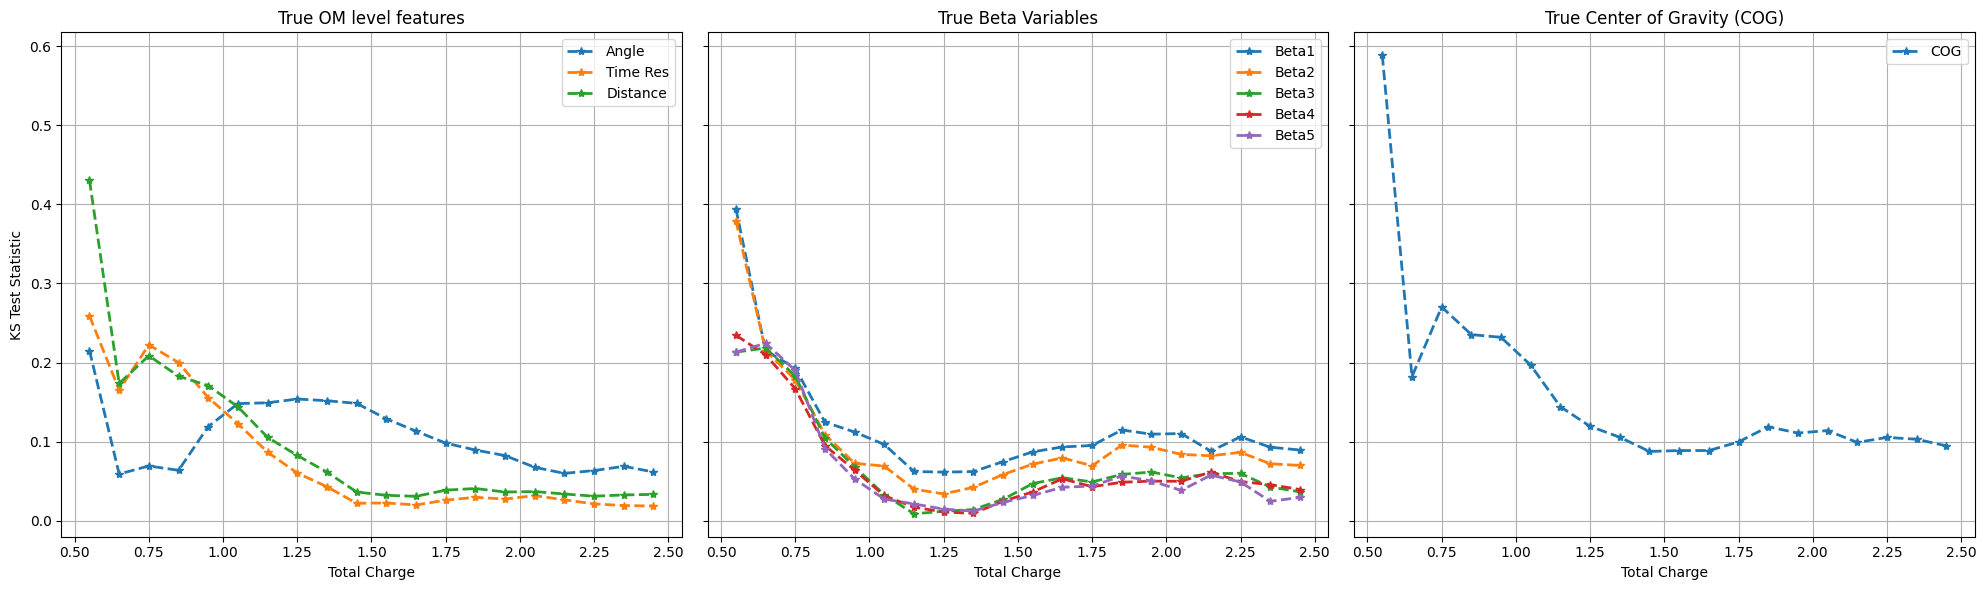

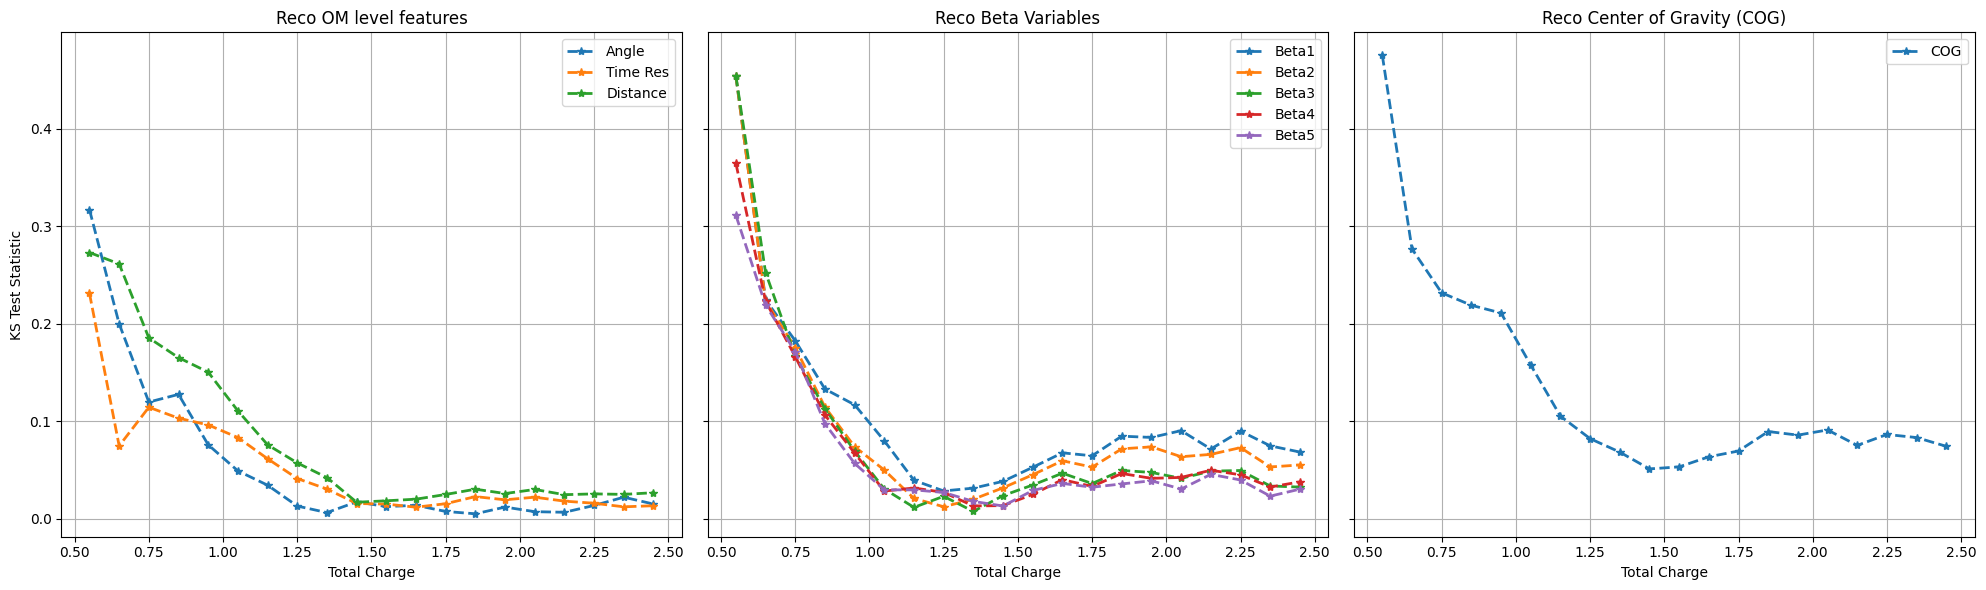

In [12]:
import matplotlib.pyplot as plt

# ---------------- Plot 1: True Energy ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].plot(bin_centers_angle_true, sep_var_angle_true, '*--', linewidth=2, label='Angle')
axs[0].plot(bin_centers_tRes_true, sep_var_tRes_true, '*--', linewidth=2, label='Time Res')
axs[0].plot(bin_centers_distance_true, sep_var_distance_true, '*--', linewidth=2, label='Distance')
axs[0].set_title('OM level features')
axs[0].set_xlabel('True Energy')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].plot(bin_centers_beta1_true, sep_var_beta1_true, '*--', linewidth=2, label='Beta1')
axs[1].plot(bin_centers_beta2_true, sep_var_beta2_true, '*--', linewidth=2, label='Beta2')
axs[1].plot(bin_centers_beta3_true, sep_var_beta3_true, '*--', linewidth=2, label='Beta3')
axs[1].plot(bin_centers_beta4_true, sep_var_beta4_true, '*--', linewidth=2, label='Beta4')
axs[1].plot(bin_centers_beta5_true, sep_var_beta5_true, '*--', linewidth=2, label='Beta5')
axs[1].set_title('Beta Variables')
axs[1].set_xlabel('True Energy')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].plot(bin_centers_cog_true, sep_var_cog_true, '*--', linewidth=2, label='COG')
axs[2].set_title('Center of Gravity (COG)')
axs[2].set_xlabel('True Energy')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ---------------- Plot 2: Reco Energy ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=2, label='Angle')
axs[0].plot(bin_centers_tRes_reco, sep_var_tRes_reco, '*--', linewidth=2, label='Time Res')
axs[0].plot(bin_centers_distance_reco, sep_var_distance_reco, '*--', linewidth=2, label='Distance')
axs[0].set_title('OM level features')
axs[0].set_xlabel('Reco Energy')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].plot(bin_centers_beta1_reco, sep_var_beta1_reco, '*--', linewidth=2, label='Beta1')
axs[1].plot(bin_centers_beta2_reco, sep_var_beta2_reco, '*--', linewidth=2, label='Beta2')
axs[1].plot(bin_centers_beta3_reco, sep_var_beta3_reco, '*--', linewidth=2, label='Beta3')
axs[1].plot(bin_centers_beta4_reco, sep_var_beta4_reco, '*--', linewidth=2, label='Beta4')
axs[1].plot(bin_centers_beta5_reco, sep_var_beta5_reco, '*--', linewidth=2, label='Beta5')
axs[1].set_title('Beta Variables')
axs[1].set_xlabel('Reco Energy')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].plot(bin_centers_cog_reco, sep_var_cog_reco, '*--', linewidth=2, label='COG')
axs[2].set_title('Center of Gravity (COG)')
axs[2].set_xlabel('Reco Energy')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ---------------- Plot 3: Total Charge (True) ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].plot(cbin_centers_angle_true, csep_var_angle_true, '*--', linewidth=2, label='Angle')
axs[0].plot(cbin_centers_tRes_true, csep_var_tRes_true, '*--', linewidth=2, label='Time Res')
axs[0].plot(cbin_centers_distance_true, csep_var_distance_true, '*--', linewidth=2, label='Distance')
axs[0].set_title('True OM level features')
axs[0].set_xlabel('Total Charge')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].plot(cbin_centers_beta1_true, csep_var_beta1_true, '*--', linewidth=2, label='Beta1')
axs[1].plot(cbin_centers_beta2_true, csep_var_beta2_true, '*--', linewidth=2, label='Beta2')
axs[1].plot(cbin_centers_beta3_true, csep_var_beta3_true, '*--', linewidth=2, label='Beta3')
axs[1].plot(cbin_centers_beta4_true, csep_var_beta4_true, '*--', linewidth=2, label='Beta4')
axs[1].plot(cbin_centers_beta5_true, csep_var_beta5_true, '*--', linewidth=2, label='Beta5')
axs[1].set_title('True Beta Variables')
axs[1].set_xlabel('Total Charge')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].plot(cbin_centers_cog_true, csep_var_cog_true, '*--', linewidth=2, label='COG')
axs[2].set_title('True Center of Gravity (COG)')
axs[2].set_xlabel('Total Charge')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ---------------- Plot 4: Total Charge (Reco) ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].plot(cbin_centers_angle_reco, csep_var_angle_reco, '*--', linewidth=2, label='Angle')
axs[0].plot(cbin_centers_tRes_reco, csep_var_tRes_reco, '*--', linewidth=2, label='Time Res')
axs[0].plot(cbin_centers_distance_reco, csep_var_distance_reco, '*--', linewidth=2, label='Distance')
axs[0].set_title('Reco OM level features')
axs[0].set_xlabel('Total Charge')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].plot(cbin_centers_beta1_reco, csep_var_beta1_reco, '*--', linewidth=2, label='Beta1')
axs[1].plot(cbin_centers_beta2_reco, csep_var_beta2_reco, '*--', linewidth=2, label='Beta2')
axs[1].plot(cbin_centers_beta3_reco, csep_var_beta3_reco, '*--', linewidth=2, label='Beta3')
axs[1].plot(cbin_centers_beta4_reco, csep_var_beta4_reco, '*--', linewidth=2, label='Beta4')
axs[1].plot(cbin_centers_beta5_reco, csep_var_beta5_reco, '*--', linewidth=2, label='Beta5')
axs[1].set_title('Reco Beta Variables')
axs[1].set_xlabel('Total Charge')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].plot(cbin_centers_cog_reco, csep_var_cog_reco, '*--', linewidth=2, label='COG')
axs[2].set_title('Reco Center of Gravity (COG)')
axs[2].set_xlabel('Total Charge')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()


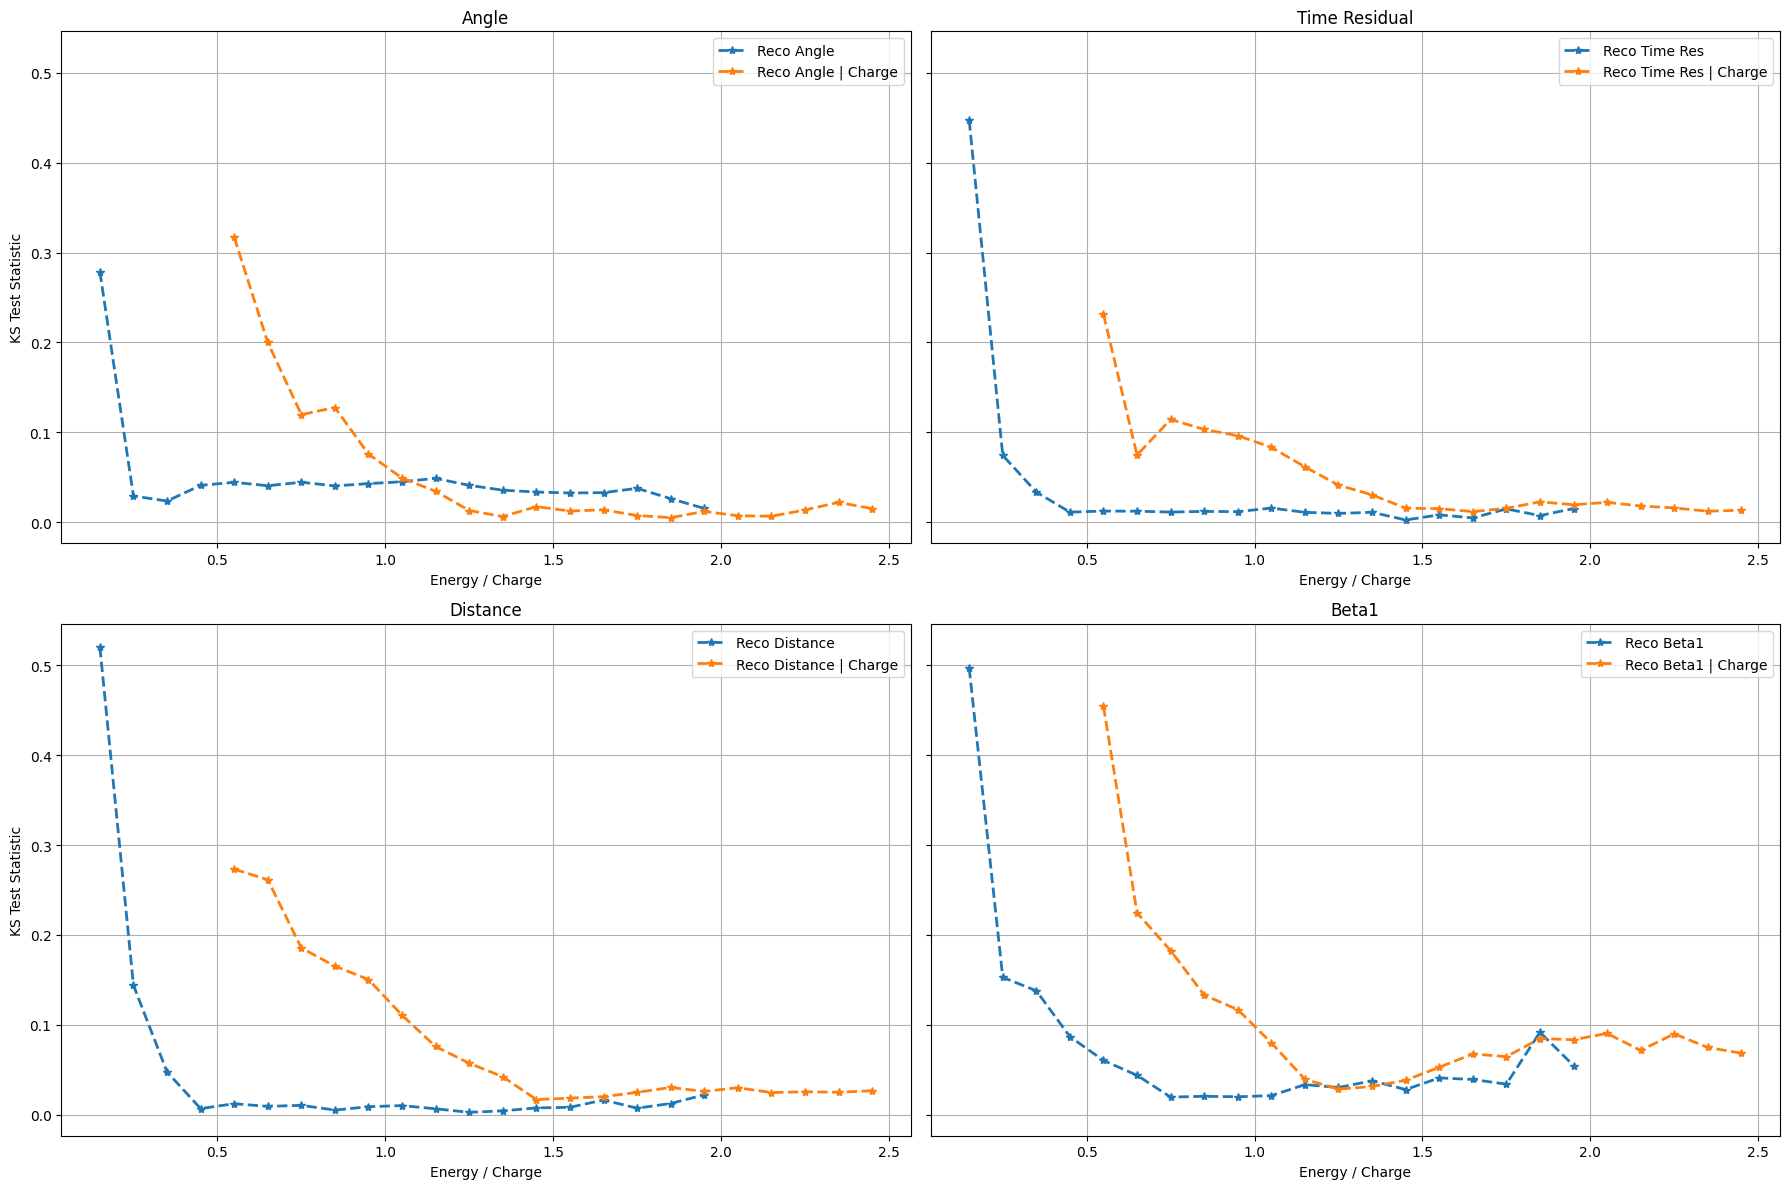

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12), sharey=True)

# Subplot 1: Angle
#axs[0, 0].plot(bin_centers_angle_true, sep_var_angle_true, '*--', linewidth=2, label='True Angle')
axs[0, 0].plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=2, label='Reco Angle')
#axs[0, 0].plot(cbin_centers_angle_true, csep_var_angle_true, '*--', linewidth=2, label='True Angle | Charge')
axs[0, 0].plot(cbin_centers_angle_reco, csep_var_angle_reco, '*--', linewidth=2, label='Reco Angle | Charge')
axs[0, 0].set_title('Angle')
axs[0, 0].set_xlabel('Energy / Charge')
axs[0, 0].set_ylabel('KS Test Statistic')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Subplot 2: Time Residual
#axs[0, 1].plot(bin_centers_tRes_true, sep_var_tRes_true, '*--', linewidth=2, label='True Time Res')
axs[0, 1].plot(bin_centers_tRes_reco, sep_var_tRes_reco, '*--', linewidth=2, label='Reco Time Res')
#axs[0, 1].plot(cbin_centers_tRes_true, csep_var_tRes_true, '*--', linewidth=2, label='True Time Res | Charge')
axs[0, 1].plot(cbin_centers_tRes_reco, csep_var_tRes_reco, '*--', linewidth=2, label='Reco Time Res | Charge')
axs[0, 1].set_title('Time Residual')
axs[0, 1].set_xlabel('Energy / Charge')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Subplot 3: Distance
#axs[1, 0].plot(bin_centers_distance_true, sep_var_distance_true, '*--', linewidth=2, label='True Distance')
axs[1, 0].plot(bin_centers_distance_reco, sep_var_distance_reco, '*--', linewidth=2, label='Reco Distance')
#axs[1, 0].plot(cbin_centers_distance_true, csep_var_distance_true, '*--', linewidth=2, label='True Distance | Charge')
axs[1, 0].plot(cbin_centers_distance_reco, csep_var_distance_reco, '*--', linewidth=2, label='Reco Distance | Charge')
axs[1, 0].set_title('Distance')
axs[1, 0].set_xlabel('Energy / Charge')
axs[1, 0].set_ylabel('KS Test Statistic')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Subplot 4: Beta1
#axs[1, 1].plot(bin_centers_beta1_true, sep_var_beta1_true, '*--', linewidth=2, label='True Beta1')
axs[1, 1].plot(bin_centers_beta1_reco, sep_var_beta1_reco, '*--', linewidth=2, label='Reco Beta1')
#axs[1, 1].plot(cbin_centers_beta1_true, csep_var_beta1_true, '*--', linewidth=2, label='True Beta1 | Charge')
axs[1, 1].plot(cbin_centers_beta1_reco, csep_var_beta1_reco, '*--', linewidth=2, label='Reco Beta1 | Charge')
axs[1, 1].set_title('Beta1')
axs[1, 1].set_xlabel('Energy / Charge')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

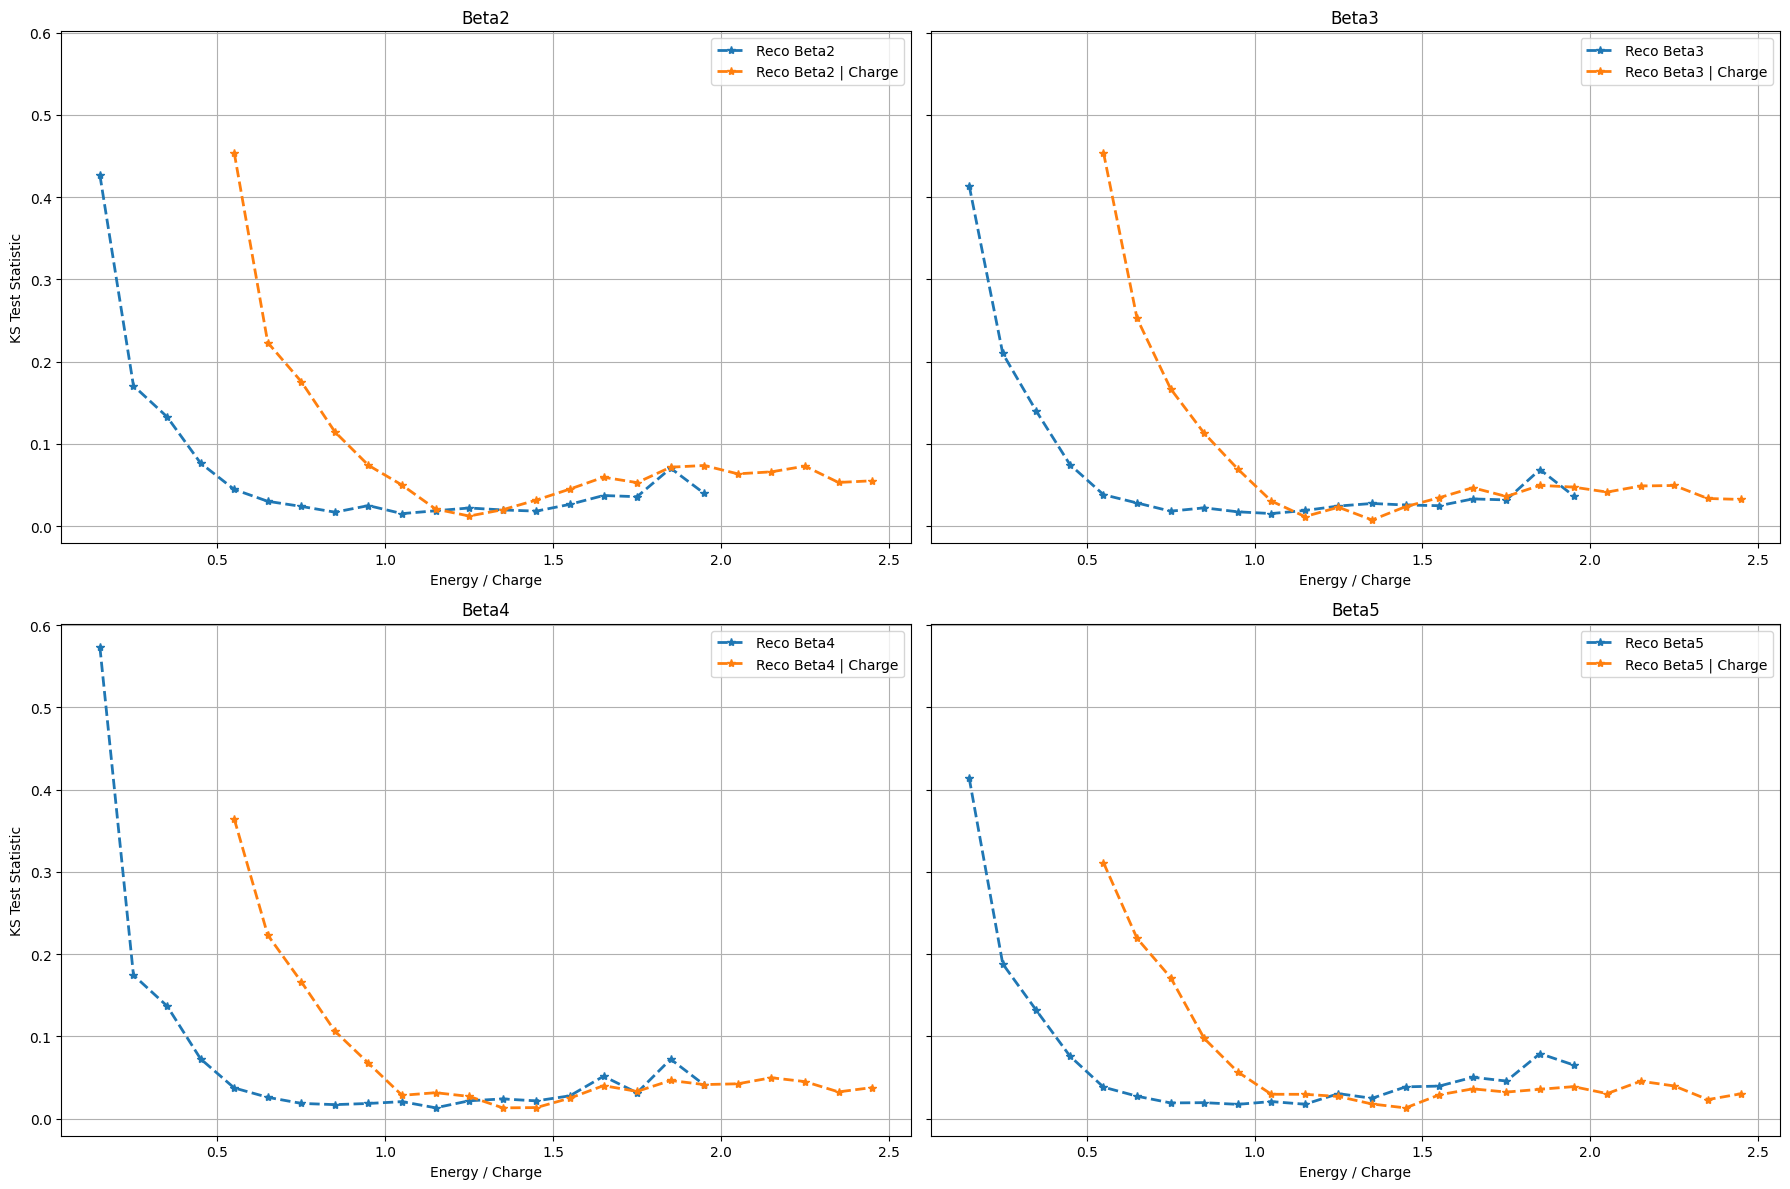

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12), sharey=True)

# Subplot 1: Angle
#axs[0, 0].plot(bin_centers_beta2_true, sep_var_beta2_true, '*--', linewidth=2, label='True Beta2')
axs[0, 0].plot(bin_centers_beta2_reco, sep_var_beta2_reco, '*--', linewidth=2, label='Reco Beta2')
#axs[0, 0].plot(cbin_centers_beta2_true, csep_var_beta2_true, '*--', linewidth=2, label='True Beta2 | Charge')
axs[0, 0].plot(cbin_centers_beta2_reco, csep_var_beta2_reco, '*--', linewidth=2, label='Reco Beta2 | Charge')
axs[0, 0].set_title('Beta2')
axs[0, 0].set_xlabel('Energy / Charge')
axs[0, 0].set_ylabel('KS Test Statistic')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Subplot 2: Time Resolution
#axs[0, 1].plot(bin_centers_beta3_true, sep_var_beta3_true, '*--', linewidth=2, label='True Beta3')
axs[0, 1].plot(bin_centers_beta3_reco, sep_var_beta3_reco, '*--', linewidth=2, label='Reco Beta3')
#axs[0, 1].plot(cbin_centers_beta3_true, csep_var_beta3_true, '*--', linewidth=2, label='True Beta3 | Charge')
axs[0, 1].plot(cbin_centers_beta3_reco, csep_var_beta3_reco, '*--', linewidth=2, label='Reco Beta3 | Charge')
axs[0, 1].set_title('Beta3')
axs[0, 1].set_xlabel('Energy / Charge')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Subplot 3: Distance
#axs[1, 0].plot(bin_centers_beta4_true, sep_var_beta4_true, '*--', linewidth=2, label='True Beta4')
axs[1, 0].plot(bin_centers_beta4_reco, sep_var_beta4_reco, '*--', linewidth=2, label='Reco Beta4')
#axs[1, 0].plot(cbin_centers_beta4_true, csep_var_beta4_true, '*--', linewidth=2, label='True Beta4 | Charge')
axs[1, 0].plot(cbin_centers_beta4_reco, csep_var_beta4_reco, '*--', linewidth=2, label='Reco Beta4 | Charge')
axs[1, 0].set_title('Beta4')
axs[1, 0].set_xlabel('Energy / Charge')
axs[1, 0].set_ylabel('KS Test Statistic')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Subplot 4: Beta1
#axs[1, 1].plot(bin_centers_beta5_true, sep_var_beta5_true, '*--', linewidth=2, label='True Beta5')
axs[1, 1].plot(bin_centers_beta5_reco, sep_var_beta5_reco, '*--', linewidth=2, label='Reco Beta5')
#axs[1, 1].plot(cbin_centers_beta5_true, csep_var_beta5_true, '*--', linewidth=2, label='True Beta5 | Charge')
axs[1, 1].plot(cbin_centers_beta5_reco, csep_var_beta5_reco, '*--', linewidth=2, label='Reco Beta5 | Charge')
axs[1, 1].set_title('Beta5')
axs[1, 1].set_xlabel('Energy / Charge')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

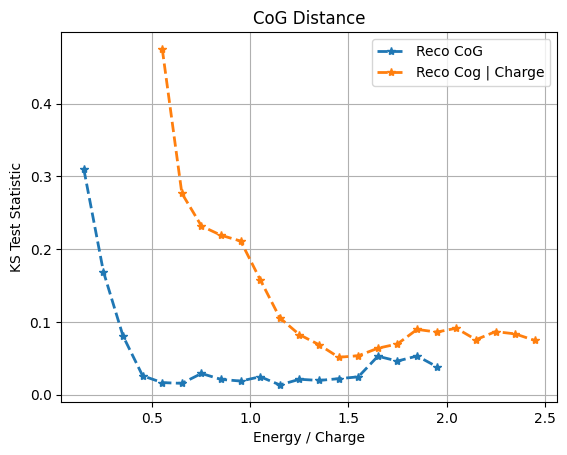

In [21]:
#plt.plot(bin_centers_cog_true, sep_var_cog_true, '*--', linewidth=2, label='True CoG')
plt.plot(bin_centers_cog_reco, sep_var_cog_reco, '*--', linewidth=2, label='Reco CoG')
#plt.plot(cbin_centers_cog_true, csep_var_cog_true, '*--', linewidth=2, label='True CoG | Charge')
plt.plot(cbin_centers_cog_reco, csep_var_cog_reco, '*--', linewidth=2, label='Reco Cog | Charge')
plt.title('CoG Distance')
plt.xlabel('Energy / Charge')
plt.ylabel('KS Test Statistic')
plt.legend()
plt.grid(True)